# 전력 Peak · 비용 최적화 — 날씨와 목표 생산량 기반 1~9월 인원 배치 (MILP)

월 · 2주 생산 목표를 지키면서 **월 최대 전력 Peak를 낮추고**, 그다음 **인건비 + 전기요금 + 위험 패널티**를 최소화하도록
근무일별 라인 가동 시간 · 시간별 생산량 · 일용직 근무 배치를 정한다.

- **입력**: `okm_augumented_2021_processed.xlsx` (선택: `enhanced_results.pkl` — 보강+보정 LSTM 예측 결과)
- **출력**: `Optimizing31_MILP_결과.xlsx`, `인원배치표_1-9월.xlsx`, `하루목표별_인원배치.xlsx`, `일일_인원배치_*.xlsx / .png`
- **솔버**: `scipy.optimize.milp` (HiGHS)

### 전체 흐름

| 절 | 내용 |
|---|---|
| 1 | 설정 (생산 목표 · 근무 규칙 · 라인 운영 · 안전마진 · 패널티) |
| 2 | 데이터 · 근무일(08시 시작 24시간 블록) · 일용직 근무패턴 생성 |
| 3 | 전력 예측 모델 · 보강+보정 LSTM 연결 · 과소예측 진단 · 차등 안전마진 · 1인당 생산량 ML |
| 3-2 | 가동 상태 전력 예측의 오차 요인 분석 |
| 4 | 최적화: (A) 라인 · 생산 MILP ↔ (B) 일별 정수 근무패턴 배치 반복 |
| 5 | 월별 리포트 · 제약 검증 / 5-2 인건비 분해 |
| 6 | 결과 엑셀 저장 |
| 7 | 시각화 (비용 · 가동 · 과소예측 지도) |
| 8 | 1~9월 인원 배치표 엑셀 |
| 9 | 하루 목표 생산량별 인원 배치 (1 · 4 · 7월 대표일 × 10,000 ~ 25,000개) |
| 10 | 월 · 하루 생산량 · 강수 유무 입력 → 그날의 최적 인원 배치 |

### 주요 규칙

**안전마진 (과소예측 방지)**
- 마진(시간, 달) = 시간대 계수 × 달 계수 — 시간 순서 검증 오차의 **과소예측 95분위**로 추정
- 마진은 **생산량 > 0 인 가동 시간에만** 적용 (`OFF_MARGIN_QUANTILE = 0.0`). `None`이면 라인 종료 후에도 95% 마진을 적용하는 보수 시나리오
- 보강+보정 LSTM 연결 시 성능 개선(확장 윈도우 MAE 8.74 → 6.34, RMSE 12.72 → 9.45)을 반영해 마진을 15% 축소 (`MARGIN_SCALE = 0.85`). `MARGIN_FROM_LSTM_ERRORS = True`면 LSTM의 실제 오차로 마진을 다시 추정
- 예측 + 마진은 해당 상태에서 관측된 최대값을 넘지 않도록 상한 (`CAP_AT_OBSERVED_MAX`)
- 기온 × 생산량 기반 요인 마진도 비교했으나 계절 이동(7월)을 못 잡아 최저 달 커버율이 낮아(Peak 86% vs 93%) 채택하지 않음

**일용직 근무 규칙**
- 짧은 근무: 2 · 3 · 4시간 (쉬지 않고 연속 근무)
- 5시간 이상: 30분 단위 (5, 5.5, 6, … 최대 12시간)
- 무급 휴게: 5~8시간 근무 1시간, 8.5시간 이상 1시간씩 두 번. 출근 직후 · 퇴근 직전만 아니면 근무 중간 아무 때나
- 연속 근무 시간 제한 없음 (`MAX_WORK_STRETCH = None`)
- 단기(5시간 미만) 근무자는 그날 고용 인원의 50% 미만 (`MAX_SHORT_SHIFT_SHARE = 0.5`)
- 임금: 9~17시 1.0배, 그 외 1.5배

**라인 · 생산**
- 근무일은 08시에 가동을 시작하고, 생산을 다 채우면 종료 (중간 정지 없이 연속 가동, 최소 8시간)
- 가동 시 시간별 생산량은 기준 생산량의 50% ~ 150%
- 월 · 시간대별 생산 상한 상향 (`BOOST_RULES`): 3 · 5월 낮 175%, 6 · 8월 낮 230%, 7월 낮 300%, 7월 07~08시 · 저녁(18~23시) 200%. 단, 기존 시간당 생산 99분위 이하 (설비 안전장치)
- 1인당 생산량은 ML(하위 30% 분위, 보수적)로 예측
- 주말 · 휴무일은 기존 값 유지

### 전력 예측 오차가 크게 나는 상황 (생산 시간 기준)
`Error_Driver_Pipeline.ipynb` 분석 + 이 노트북 3-2절 결과

| 상황 | 결과 |
|---|---|
| **생산량 · 인원 많음** | 영향 큼 (하위 20% 1% vs 상위 40% 11~12%) |
| **더운 날 (≥ 28℃)** | 영향 큼, 특히 생산이 많을 때 (생산 높음 + ≥ 28℃: 49.5%, 생산 낮음은 기온과 무관하게 0~2%). 같은 달 안 · 예측 구간만 봐도 유지 |
| **아침 07~11시 (근무 시작 무렵)** | 생산량이 적어도 큰 과소예측 11~17% (다른 시간 1~3%) |
| 풍속 · 풍속 변화 · 비 · 라인 재가동 후 경과시간 | 영향 없음 |

### 결과 해석 시 주의
- Peak · 전력비의 '최적' 값은 **실측 기준 환산**이다 (기존 상태는 실측, 상태가 바뀐 시간만 예측 + 마진).
- 라인을 끈 시간은 마진 없는 예측이므로 **전력 절감은 기대값**이며, 라인 종료 후 전력은 19건 표본으로 추정해 불확실하다.
- 인건비는 (1) 기존 기록, (2) **[공정비교] 같은 근무규칙을 적용한 기존 운영** 두 기준으로 비교한다.
- 인건비 증가의 대부분은 최적화가 아니라 **근무규칙 비용**(정수 인원 · 최소 근무시간 · 무급 휴게)이며, 최소 근로시간 설정(`MIN_SHIFT_WORK_HOURS`)의 영향이 가장 크다 (5-2절).

## 1. 설정

In [1]:
# ============================================================
# Optimizing31 - 날씨 + 목표 생산량으로 1~9월 인원 배치 (MILP)
#  안전마진(과소예측 방지) / 일용직 근무 규칙 / 1인당 생산량 ML / 라인 연속 가동(중간 무가동 없음)
# ============================================================
import numpy as np, pandas as pd, time, warnings
from scipy.optimize import milp, LinearConstraint, Bounds, lsq_linear, linprog
from scipy.sparse import csr_matrix
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
warnings.filterwarnings("ignore")

FILE_PATH = "okm_augumented_2021_processed.xlsx"
OUT_PATH  = "Optimizing31_MILP_결과.xlsx"
ROSTER_PATH = "인원배치표_1-9월.xlsx"          # 8절에서 출력하는 1~9월 인원 배치표

# ---- 기본 단위 ----
PERSONNEL_SCALE = 10                 # '공장인원' 컬럼 -> 실제 인원 환산 배율
HOURLY_WAGE     = 10_320             # 시급(원)
def wage_multiplier(h): return 1.0 if 9 <= h <= 17 else 1.5               # 9~17시 1.0배, 그 외 시간 1.5배

# ---- 생산량 목표 ----
MONTHLY_PRODUCTION_RATIO  = 1.00     # 월 생산량 >= 기존(목표)의 100%
BIWEEKLY_PRODUCTION_RATIO = 1.00     # 2주 생산량 >= 기존(목표)의 100%
BIWEEK_DAYS               = 14
MAX_PRODUCTION_RATIO      = 1.50     # 라인 가동 시 시간별 생산량: 기준 생산량의 50% ~ 150%
MIN_PRODUCTION_RATIO      = 0.50     #   (기준 = 기존 생산량, 기존에 쉬던 시간은 같은 시각 가동시간의 중앙값) -> 가동 중 무가동 시간이 생기지 않음
# 월·시간대별 시간당 생산 상한 상향 규칙: (월 목록, (시작시, 끝시) 포함, 상한 배율). 기본 상한 = MAX_PRODUCTION_RATIO(1.5)
BOOST_RULES = [((3, 5), (9, 17), 1.75),    # 3·5월 낮(09~17시): 175%
               ((6, 8), (9, 17), 2.3),      # 6·8월 낮(09~17시): 230%
               ((7,), (9, 17), 3.0),        # 7월 낮(09~17시): 300% (낮에 더 몰기)
               ((7,), (7, 8), 2.0),         # 7월 07~08시: 200%
               ((7,), (18, 23), 2.0)]       # 7월 저녁(18~23시): 200%
BOOST_CAP_QUANTILE = 0.99              # 상한을 올린 시간도 기존 시간당 생산의 99분위(약 4,700개/시간)를 넘지 않게 (설비 능력 안전장치). 기존 150% 한도보다 낮아지지는 않음
PRODUCTION_PACE_RATIO     = 1.00     # 월 중 누적 생산 >= 기존 누적 (None이면 해제)
# 인원 총량(person-hour) 제한 없음: 생산량만 맞추면 인원은 늘거나 줄 수 있음

# ---- 일용직 근무 규칙 ----
SHORT_SHIFT_HOURS   = [2, 3, 4]        # 짧은 일용직의 실근로시간(시간). 4시간 이하는 쉬지 않고 시작부터 연속 근무
LONG_SHIFT_MIN      = 5.0              # 5시간 이상 근무 그룹부터는 고용시간을 30분 단위로 (5, 5.5, 6, 6.5, ...)
LONG_SHIFT_STEP     = 0.5
MAX_SHIFT_WORK_HOURS = 12              # 최대 실근로시간
BREAK_RULE          = [(4, 0), (8, 1), (12, 2)]   # (실근로시간 상한, 무급 휴게 횟수[1회=1시간]): 4시간 이하 0 / 5~8시간 1시간 / 8.5시간 이상 2시간
MAX_WORK_STRETCH    = None             # 연속 근무 시간 제한 없음. 무급 휴게(1시간)는 처음·마지막 시간만 아니면 근무 중간 아무 때나. 숫자(예: 4)를 넣으면 그 시간 초과 연속 근무 금지
MAX_SHORT_SHIFT_SHARE = 0.5            # 그날 고용 인원 중 5시간 미만(단기) 근무자 비율은 이 값 미만 (SHORT_SHARE_STRICT=True면 엄밀히 미만). None이면 제한 없음
SHORT_SHARE_STRICT  = True
PRUNE_K             = 300              # 일별 정수 배치에서 LP 환산비용이 작은 상위 패턴 K개로 후보를 줄여 속도 확보 (패턴이 매우 많을 때)
MIN_SHIFT_WORK_HOURS = min(SHORT_SHIFT_HOURS)

# ---- 라인 운영 ----
LINE_START_HOUR = 8                  # 근무일은 08시에 시작
MIN_LINE_HOURS  = 8                  # 근무일 최소 가동시간
ALLOW_LINE_STOP = True               # True: 생산을 다 채우면 라인 종료(이후 다음날 08시까지 정지). False: 항상 가동
WEEKEND_FIXED   = True               # 주말/휴무일은 기존 값 그대로

# ---- 전력 예측 + 안전마진 (과소예측 방지) ----
POWER_MODE = "weather"               # "weather": 날씨·시각·상태로 전력을 예측(+안전마진) / "anchor": 기존 실측값 기준(바뀌는 시간만 예측+마진)
CLEAN_MONTHS = [4, 5, 7, 8, 9]       # 전력 패턴이 복제된 것으로 의심되는 1·2·3·6월은 학습에서 제외
OFF_MARGIN_QUANTILE = 0.0            # 안전마진은 생산량 > 0 인 시간에만 적용. 라인을 끈(생산 0) 시간은 마진 없음(0). None으로 두면 MARGIN_QUANTILE(0.95)을 적용(보수 시나리오)
MARGIN_QUANTILE    = 0.95            # 과소예측 오차의 95% 분위를 안전마진으로 사용
WIND_VAR_THRESHOLD = 0.62            # (참고용) 월 풍속 변동성 그룹. 과소예측 분석 결과 오차와 맞지 않아 안전마진 계산에는 더 이상 쓰지 않음
MONTH_FACTOR_MIN, MONTH_FACTOR_MAX = 0.5, 1.6   # 달 계수 범위 (마진 = 시간대 계수 x 달 계수)
CAP_AT_OBSERVED_MAX = True           # 예측+안전마진이 해당 상태(가동/라인 종료 후)에서 과거에 관측된 최대값을 넘지 않도록 상한. 마진이 커서 본 적 없는 값이 되는 것을 방지
MARGIN_ERROR_SOURCE = "time_ordered"   # 마진 계산에 쓰는 오차: "time_ordered" = 앞선 정상월로만 학습해 다음 달을 예측한 오차(계절 이동 반영, 보수적) / "lomo" = 월 단위 교차검증 오차
MARGIN_MIN_N       = 30              # 시간대 계수 추정에 필요한 최소 표본 수
# ---- 전력 예측 모델(보강+보정 LSTM) · 안전마진 축소 ----
POWER_FORECASTER = "lstm_enhanced"   # "lstm_enhanced": LSTM_AIModel_Enhanced(보강 LSTM + 잔차 보정) 예측을 가동 상태 전력 예측에 사용 (결과 파일이 있을 때) / "hgb": 기존 ML 만 사용
LSTM_RESULT_PATH = "enhanced_results.pkl"   # LSTM_Enhanced_Performance.ipynb 가 저장하는 결과 파일 (RES_82, RES_EXP)
LSTM_AUTO_TRAIN  = False             # True 이면 결과 파일이 없을 때 LSTM_AIModel_Enhanced.py 로 직접 학습 (TensorFlow 필요, CPU 약 50분)
LSTM_MODULE_DIR  = "."               # LSTM_AIModel_Enhanced.py 가 있는 폴더
MARGIN_FROM_LSTM_ERRORS = False      # True 이면 안전마진을 LSTM 의 실제 오차(확장 윈도우)로 다시 추정 -> 이때는 MARGIN_SCALE = 1.0 으로 둘 것
MARGIN_SCALE = 0.85                  # 안전마진 전체 축소 배율. LSTM 성능 개선(확장 윈도우 MAE 8.74 -> 6.34, RMSE 12.72 -> 9.45)을 반영해 15% 줄임. 1.0 = 축소 없음, 0.7 = MAE 개선분 전부 반영
# 시간대 구간 라벨
HOUR_BINS   = [-1, 5, 7, 17, 21, 23]; HOUR_LABELS = ["00-05", "06-07", "08-17", "18-21", "22-23"]

# ---- 1인당 생산량 ML ----
PROD_CAP_QUANTILE = 0.30             # 1인당 생산량 예측의 하위 30% 분위(보수적)를 용량으로 사용 -> 생산 목표 미달 위험 감소

# ---- Peak / 위험도 패널티 ----
PEAK_QUANTILE, PEAK_HISTORY_WEEKS = 0.95, 4
PEAK_LIMIT_PENALTY = 100.0
RISK_GAIN = 5.0                      # '보통 Peak보다 높을 것으로 예상되는 시간'의 Peak 초과 패널티 가중 배율
SURGE_THRESHOLD_PCT, SURGE_MIN_PEAK, SURGE_EXCESS_PENALTY = 20.0, 20.0, 50.0
TEMP_SURGE_PENALTY_MULT = 3.0
TEMP_RISE_HOURS, TEMP_RISE_LOW, TEMP_RISE_HIGH = 3, 0.5, 2.0
HEAT_TEMP, HEAT_TEMP_FULL, HEAT_HUMID, HEAT_ONLY_WEIGHT = 26.0, 30.0, 80.0, 0.9
HEAT_PEAK_PENALTY = 2000.0
ENERGY_COST_WEIGHT, LABOR_COST_WEIGHT = 1.0, 1.0

# ---- MILP 옵션 (반복 횟수 / Peak 허용오차 / 단계별 시간 제한(초) / MIP gap) ----
STAFF_ITERS = 3
PEAK_TOL = 0.0
TIME_LIMIT_1, TIME_LIMIT_2, MIP_GAP = 300, 300, 0.01
print("설정 완료 | 전력 모드:", POWER_MODE, "| 라인 정지 허용:", ALLOW_LINE_STOP)

/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (


설정 완료 | 전력 모드: weather | 라인 정지 허용: True


## 2. 데이터 · 근무일 구조 · 일용직 근무패턴

In [2]:
# ============================================================
# 데이터 / 근무일(08시 시작) / 풍속 변동(참고) / 일용직 근무패턴
# ============================================================
df = pd.read_excel(FILE_PATH)
df["datetime"] = pd.to_datetime(df["datetime"]); df = df.sort_values("datetime").reset_index(drop=True)
df["hour"], df["month"], df["dow"] = df["datetime"].dt.hour, df["datetime"].dt.month, df["datetime"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["n0"], df["p0"] = df["공장인원"] * PERSONNEL_SCALE, df["생산량"].astype(float)
df["P0"], df["E0"] = df["전력 최대값"].astype(float), df["전력 구간합계"].astype(float)
df["tariff"] = df["전기요금(계절)"].astype(float); df["wage"] = HOURLY_WAGE * df["hour"].map(wage_multiplier)
assert (df["datetime"].diff().dropna() == pd.Timedelta(hours=1)).all(), "1시간 간격이 아닌 구간이 있습니다"
T = len(df); months = [int(m) for m in sorted(df["month"].unique())]; M = len(months)
midx = df["month"].map({m: i for i, m in enumerate(months)}).values
hour = df["hour"].values
p0, n0, P0, E0, tariff, wage = (df[c].values.astype(float) for c in ["p0", "n0", "P0", "E0", "tariff", "wage"])
day0 = (df["datetime"].dt.normalize() - df["datetime"].min().normalize()).dt.days.values; win = day0 // BIWEEK_DAYS

# ---- 근무일 = 08시에 시작해 다음날 07시에 끝나는 24시간 블록 ----
df["sday"] = (df["datetime"] - pd.Timedelta(hours=LINE_START_HOUR)).dt.normalize()
df["sday_dow"] = df["sday"].dt.dayofweek
df["sday_prod"] = df.groupby("sday")["p0"].transform("sum"); df["sday_len"] = df.groupby("sday")["p0"].transform("size")
df["dec"] = ((df["sday_dow"] < 5) if WEEKEND_FIXED else True) & (df["sday_len"] == 24) & (df["sday_prod"] > 0)
dec = df["dec"].values
BLOCKS = [g.index.values for _, g in df[dec].groupby("sday")]
assert all(len(b) == 24 and b[-1] - b[0] == 23 and hour[b[0]] == LINE_START_HOUR for b in BLOCKS)
D = len(BLOCKS); on0 = dec & (p0 > 0); off0 = dec & (p0 <= 0)
off_in_block = np.zeros(T, int)
for b in BLOCKS: off_in_block[b] = np.arange(24)                               # 08시 기준 offset


# ---- 무가동 시간의 위치: 0=생산 없는 날 / 1=첫 생산 이전(예열) / 2=생산 사이 공백 / 3=마지막 생산 이후(꼬리, 라인 종료 후) ----
_g = df.groupby("sday")["p0"]; _cum = _g.transform(lambda s: (s > 0).cumsum()); _tot = _g.transform(lambda s: (s > 0).sum())
df["pos"] = np.where(df["sday_prod"] <= 0, 0, np.where(_cum == 0, 1, np.where(_cum == _tot, 3, 2)))

# ---- 기준 생산량: 기존 생산량, 기존에 쉬던 시간은 같은 시각 가동시간의 중앙값 ----
typ = df[dec & (p0 > 0)].groupby("hour")["p0"].median()
p_ref = np.where(p0 > 0, p0, df["hour"].map(typ).fillna(typ.median()).values)

# ---- 월별 풍속 변동성 (참고용, 안전마진 계산에는 미사용) ----
HOUR_TO_BAND = {h: HOUR_LABELS[np.searchsorted(HOUR_BINS[1:], h)] for h in range(24)}
df["band"] = df["hour"].map(HOUR_TO_BAND)
month_wind = df.groupby("month")["풍속"].apply(lambda s: s.diff().abs().mean())
WIND_GROUP = {int(m): ("high" if v >= WIND_VAR_THRESHOLD else "low") for m, v in month_wind.items()}
df["wgrp"] = df["month"].map(WIND_GROUP)

# ---- 가동 후 경과시간(기동 여부): 기존 / 계획 ----
since_base = np.zeros(T)
c_ = 0
for t in range(T):
    c_ = min(c_ + 1, 3) if p0[t] > 0 else 0; since_base[t] = c_
since_plan = np.where(dec, np.minimum(off_in_block + 1, 3), np.maximum(since_base, 1))

# ---- 주간 Peak 기준(직전 4주) / 기온 상승 · 고온다습 위험도 ----
def build_weekly_peak_limits(d):
    ws = d["datetime"].dt.to_period("W-SUN").dt.start_time
    weekly = d.groupby(ws)["P0"].quantile(PEAK_QUANTILE).sort_index(); fb = float(d["P0"].quantile(PEAK_QUANTILE)); lim = {}
    for w in sorted(ws.unique()):
        prior = weekly[weekly.index < w].tail(PEAK_HISTORY_WEEKS); lim[pd.Timestamp(w)] = float(prior.quantile(0.95)) if len(prior) else fb
    return lim
_wl = build_weekly_peak_limits(df)
wlim = np.array([_wl[pd.Timestamp(x)] for x in df["datetime"].dt.to_period("W-SUN").dt.start_time])
rise = (df["기온"] - df["기온"].shift(TEMP_RISE_HOURS)).fillna(0)
temp_risk = np.clip((rise - TEMP_RISE_LOW) / (TEMP_RISE_HIGH - TEMP_RISE_LOW), 0, 1).values
Tm, RH = df["기온"].values, df["습도"].values
heat_risk = np.where(Tm >= HEAT_TEMP, np.minimum(1.0, 0.5 + 0.5 * (Tm - HEAT_TEMP) / (HEAT_TEMP_FULL - HEAT_TEMP)), 0.0) * np.where(RH >= HEAT_HUMID, 1.0, HEAT_ONLY_WEIGHT)

# ---- 일용직 근무패턴 생성 ----
#  * 짧은 일용직: 2·3·4시간, 쉬지 않고 시작부터 연속 근무
#  * 5시간 이상: 30분 단위(5, 5.5, 6, ... 최대 12시간). 무급 휴게(1시간 단위)는 근무 중간 아무 때나 둘 수 있음
#      5~8시간 근무 = 휴게 1시간, 8.5시간 이상 = 휴게 2시간(1시간씩 두 번)
#  * 연속 근무 시간 제한은 없음(MAX_WORK_STRETCH=None). 휴게는 출근 직후(처음 시간)·퇴근 직전(마지막 시간)이 아니면 어디든 가능
#  * 30분은 마지막 시간(0.5 근무)으로 표현: 슬롯 W=1시간 근무, H=30분 근무(마지막 슬롯만), B=휴게 1시간
import itertools
def _nbreaks(W):
    for lim, n in BREAK_RULE:
        if W <= lim + 1e-9: return n
    return None
SHIFT_WORKS = sorted(set(float(x) for x in SHORT_SHIFT_HOURS) | set(round(float(x), 1) for x in np.arange(LONG_SHIFT_MIN, MAX_SHIFT_WORK_HOURS + 1e-9, LONG_SHIFT_STEP)))
def _stretch_ok(seq):
    if MAX_WORK_STRETCH is None: return True
    run = 0.0
    for c in seq:
        run = run + 1.0 if c == "W" else (run + 0.5 if c == "H" else 0.0)
        if run > MAX_WORK_STRETCH + 1e-9: return False
    return True
def build_patterns():
    pats = []
    for a in range(24):
        for W in SHIFT_WORKS:
            nb = _nbreaks(W); full = int(np.floor(W + 1e-9)); half = (W - full) > 1e-9
            if nb is None: continue
            span = full + (1 if half else 0) + nb
            if a + span > 24: continue
            for br in itertools.combinations(range(1, span - 1), nb):                 # 휴게는 처음·마지막 슬롯이 될 수 없음
                seq = ["B" if i in br else "W" for i in range(span)]
                if half: seq[-1] = "H"
                if _stretch_ok(seq): pats.append((a, span, tuple(seq), float(W)))
    return pats
def validate_shift(start_hour, seq):
    errs = []; W = seq.count("W") + 0.5 * seq.count("H")
    if W not in SHIFT_WORKS: errs.append("근로시간 단위")
    if seq[0] != "W" or seq[-1] not in ("W", "H"): errs.append("휴게가 시작/끝")
    if "H" in seq[:-1]: errs.append("30분 근무 위치")
    if not _stretch_ok(seq): errs.append("연속근무 4시간 초과")
    if _nbreaks(W) != seq.count("B"): errs.append("휴게 횟수")
    return errs
PAT = build_patterns(); NP = len(PAT)
COV = np.zeros((NP, 24)); HC = np.zeros((NP, 24))
for i, (a, span, seq, W) in enumerate(PAT):
    for j, c in enumerate(seq):
        if c in ("W", "H"):
            COV[i, a + j] = 1.0 if c == "W" else 0.5
            HC[i, a + j] = HOURLY_WAGE * wage_multiplier((LINE_START_HOUR + a + j) % 24) * COV[i, a + j]
IS_SHORT = np.array([p[3] < LONG_SHIFT_MIN for p in PAT]); MASK = COV > 0
PCOST = HC.sum(axis=1)                                           # 패턴 1명의 하루 임금 (무급 휴게 제외)
print(f"{T:,}시간 | 최적화 근무일 {D}일 ({int(dec.sum()):,}시간, 기존 생산시간 {int(on0.sum()):,} / 기존 중간 무가동 {int(off0.sum()):,}) | 근무패턴 {NP}개/일")
print("월별 풍속 변동성(m/s):", {int(m): round(float(v), 3) for m, v in month_wind.items()}, "\n  -> 변동 큼(전체 마진):", [m for m, g in WIND_GROUP.items() if g == "high"], "/ 변동 작음(마진 축소):", [m for m, g in WIND_GROUP.items() if g == "low"])
_cnt = pd.Series([p[3] for p in PAT]).value_counts().sort_index()
print(f"근무패턴 {NP}개/일 | 실근로시간별 패턴 수:", {float(k): int(v) for k, v in _cnt.items()})
_ex = [p for p in PAT if p[0] == 1 and p[3] == 5.5][:2] + [p for p in PAT if p[0] == 1 and p[3] == 9][:2]
print("예) 09시 시작:", [f"{p[3]}h " + "".join(p[2]) for p in _ex], " (W=1시간 근무, H=30분 근무, B=휴게 1시간)")

6,168시간 | 최적화 근무일 169일 (4,056시간, 기존 생산시간 3,483 / 기존 중간 무가동 573) | 근무패턴 5700개/일
월별 풍속 변동성(m/s): {1: 0.681, 2: 0.662, 3: 0.626, 4: 0.63, 5: 0.6, 6: 0.511, 7: 0.551, 8: 0.577, 9: 0.547} 
  -> 변동 큼(전체 마진): [1, 2, 3, 4] / 변동 작음(마진 축소): [5, 6, 7, 8, 9]
근무패턴 5700개/일 | 실근로시간별 패턴 수: {2.0: 23, 3.0: 22, 4.0: 21, 5.0: 76, 5.5: 90, 6.0: 90, 6.5: 102, 7.0: 102, 7.5: 112, 8.0: 112, 8.5: 504, 9.0: 504, 9.5: 585, 10.0: 585, 10.5: 660, 11.0: 660, 11.5: 726, 12.0: 726}
예) 09시 시작: ['5.5h WBWWWWH', '5.5h WWBWWWH', '9.0h WBBWWWWWWWW', '9.0h WBWBWWWWWWW']  (W=1시간 근무, H=30분 근무, B=휴게 1시간)


## 3. 예측 모델 · 안전마진 · 1인당 생산량
1. **전력 예측**: 가동 / 무가동 상태별 Peak · 전력량을 날씨 · 시각 · 가동 경과시간으로 예측 (월 단위 교차검증으로 모델 선택)
2. **보강+보정 LSTM 연결**: `enhanced_results.pkl`이 있으면 기존 가동 시간의 가동 상태 예측을 LSTM 예측으로 대체
3. **과소예측 진단 · 차등 안전마진**: 시간대 × 달별 과소예측 95분위로 마진 계산
4. **1인당 생산량 ML**: 예측 전력 · 날씨 · 시각 · 기동 여부로 1인당 생산량의 하위 30% 분위를 예측 (용량)

In [3]:
# ============================================================
# 모델 3종
#  (1) 전력 예측: 가동/무가동 상태별 Peak·전력량 (날씨·시각·가동경과로 ML, 월 단위 교차검증으로 모델 선택)
#  (1-b) 보강+보정 LSTM 예측 연결 (결과 파일이 있을 때 가동 상태 예측을 대체)
#  (2) 안전마진: 과소예측 오차의 95% 분위 (시간대 계수 x 달 계수)  -> 예측 + 마진 >= 실제
#  (3) 1인당 생산량: 날씨·전력 투입·시각·기동 여부로 그 시점의 1인당 생산량을 ML로 예측 (보수적 분위)
# ============================================================
F_BASE = ["hour", "dow", "month", "기온", "습도", "풍속", "강수량"]
df["since"] = since_base
def _cands():
    return {"시간대평균": None,
            "HGB": lambda: HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=150, min_samples_leaf=10),
            "ExtraTrees": lambda: ExtraTreesRegressor(300, min_samples_leaf=3, random_state=0, n_jobs=-1)}
def _pred(mk, tr, te, tgt, feats):
    if mk is None: hm = tr.groupby("hour")[tgt].mean(); return te["hour"].map(hm).fillna(tr[tgt].mean()).values
    return mk().fit(tr[feats], tr[tgt]).predict(te[feats])
def fit_state_model(train, tgt, feats):
    cv = {n: np.zeros(len(train)) for n in _cands()}
    for m in sorted(train["month"].unique()):                                 # 월 단위 leave-one-month-out
        trn, msk = train[train["month"] != m], (train["month"] == m).values
        for n, mk in _cands().items(): cv[n][msk] = _pred(mk, trn, train[msk], tgt, feats)
    score = {n: float(np.abs(train[tgt].values - cv[n]).mean()) for n in cv}; best = min(score, key=score.get); mk = _cands()[best]
    if mk is None:
        hm, mu = train.groupby("hour")[tgt].mean(), train[tgt].mean(); predict = lambda fr: np.maximum(fr["hour"].map(hm).fillna(mu).values, 0)
    else:
        mdl = mk().fit(train[feats], train[tgt]); predict = lambda fr: np.maximum(mdl.predict(fr[feats]), 0)
    return dict(best=best, score=score, oof=cv[best], predict=predict)

# ---- (1) 상태별 전력 모델 ----
on_tr = df[dec & (p0 > 0) & df["month"].isin(CLEAN_MONTHS)].copy()                                           # 근무일 가동 시간
MOD = {("on", "P"): fit_state_model(on_tr, "P0", F_BASE + ["since"]), ("on", "E"): fit_state_model(on_tr, "E0", F_BASE + ["since"])}
# 무가동 = 생산량 0 & 인원 0 인 모든 시간. 위치(pos)에 따라 전력이 크게 다름: 생산 없는 날 ~27kW / 예열 ~150kW / 생산 사이 공백 ~100kW / 마지막 생산 이후(꼬리) 중앙값 ~25kW
# -> 위치 변수를 넣어 전체 구간을 함께 학습하고, 라인을 끈 뒤 상태인 '꼬리'(pos=3)의 예측력으로 평가·마진을 계산
off_all = df[(p0 <= 0) & (n0 <= 0) & df["month"].isin(CLEAN_MONTHS)].copy()
OFF_F = F_BASE + ["pos"]; TAIL = 3
def _off_cands():
    return {"위치별 시간대평균": None,
            "HGB": lambda: HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=150, min_samples_leaf=8),
            "ExtraTrees": lambda: ExtraTreesRegressor(300, min_samples_leaf=3, random_state=0, n_jobs=-1)}
def _off_pred(mk, tr, te, tgt):
    if mk is None:
        gm, pm = tr.groupby(["pos", "hour"])[tgt].mean(), tr.groupby("pos")[tgt].mean()
        return np.array([gm.get((p_, h), pm.get(p_, tr[tgt].mean())) for p_, h in zip(te["pos"], te["hour"])])
    return mk().fit(tr[OFF_F], tr[tgt]).predict(te[OFF_F])
def fit_off(tgt):
    cv = {n: np.zeros(len(off_all)) for n in _off_cands()}
    for mo in sorted(off_all["month"].unique()):
        trn, msk = off_all[off_all["month"] != mo], (off_all["month"] == mo).values
        for n, mk in _off_cands().items(): cv[n][msk] = _off_pred(mk, trn, off_all[msk], tgt)
    reg = (off_all["pos"] == TAIL).values
    score = {n: float(np.abs(off_all[tgt].values[reg] - cv[n][reg]).mean()) for n in cv}; best = min(score, key=score.get); mk = _off_cands()[best]
    mdl = mk().fit(off_all[OFF_F], off_all[tgt]) if mk is not None else None
    def predict(fr):
        fr = fr.copy(); fr["pos"] = TAIL                                                   # 계획에서 꺼진 시간 = 마지막 생산 이후
        return np.maximum(_off_pred(mk, off_all, fr, tgt) if mk is None else mdl.predict(fr[OFF_F]), 0)
    return dict(best=best, score=score, oof=cv[best][reg], predict=predict)
MOD[("off", "P")] = fit_off("P0"); MOD[("off", "E")] = fit_off("E0")
off_tr = off_all[off_all["pos"] == TAIL].copy()                                           # 평가·마진 기준 표본(라인 종료 후)
holiday = off_all[off_all["pos"] == 0]
_pm = off_all.groupby("pos")["P0"].agg(["count", "mean", "median"]).round(0)
print(f"[전력 모델] 가동 학습 {len(on_tr)}h | 무가동(생산·인원 0) 학습 {len(off_all)}h  (Peak kW: " + ", ".join(f"{n_}={int(r['mean'])}(중앙 {int(r['median'])}, {int(r['count'])}h)" for n_, r in zip(['생산없는날','예열','공백','꼬리'], _pm.iloc)) + f")")
print(f"  -> 라인 종료 후 상태 = 꼬리 {len(off_tr)}h 기준으로 평가 (표본이 적으므로 안전마진이 큼)")
for (st, tg), mm_ in MOD.items(): print(f"  {st:3s} {tg}: 교차검증 MAE { {k: round(v, 1) for k, v in mm_['score'].items()} } -> {mm_['best']}")

# ---- (2) 안전마진: 과소예측이 큰 구간(시간대·달)은 크게, 정확한 구간은 작게 ----
#  (a) 진단: 모든 달에서 '학습에 쓰이지 않은' 예측오차 (정상월 = 월 단위 교차검증, 1·2·3·6월 = 정상월로 학습한 모델로 예측)
def under_frame(tgt_key, col):
    rows = df[dec & (p0 > 0)]; fr = rows[F_BASE].copy(); fr["since"] = np.maximum(since_base, 1)[rows.index]
    pred = pd.Series(MOD[("on", tgt_key)]["predict"](fr), index=rows.index); pred.loc[on_tr.index] = MOD[("on", tgt_key)]["oof"]
    out = pd.DataFrame({"month": rows["month"], "hour": rows["hour"], "actual": rows[col], "pred": pred}); out["err"] = out["actual"] - out["pred"]; return out
UF = {"P": under_frame("P", "P0"), "E": under_frame("E", "E0")}
#  시간 순서 검증: 앞선 정상월로만 학습해 다음 달을 예측 (예: 4+5월 -> 7월). 계절이 바뀌는 첫 달은 과소예측이 훨씬 크므로(7월 95분위 24 -> 46kW) 월 교차검증만으로는 마진이 부족
def time_ordered_errors(tgt_key, col, e):
    e = e.copy(); mk = _cands()[MOD[("on", tgt_key)]["best"]]
    for mo in sorted(on_tr["month"].unique()):
        prev = on_tr[on_tr["month"] < mo]
        if prev["month"].nunique() == 0: continue
        te = on_tr[on_tr["month"] == mo]; e.loc[te.index, "err"] = te[col].values - _pred(mk, prev, te, col, F_BASE + ["since"])
    return e
UF_LOMO = {k: v.copy() for k, v in UF.items()}
if MARGIN_ERROR_SOURCE == "time_ordered": UF = {"P": time_ordered_errors("P", "P0", UF["P"]), "E": time_ordered_errors("E", "E0", UF["E"])}
# ---- (1-b) 보강+보정 LSTM 전력 예측 연결 (LSTM_AIModel_Enhanced.py) ----
#  LSTM 은 '평균'(시간 평균 전력, kW)을 1시간 앞 예측한다 (직전 24시간 실측 + 계획·예보 값 입력).
#   - 전력량(구간합계) = 4 x 평균 (데이터에서 3.992 ± 0.03),  Peak(최대값) = 시간대별 절편 + 공통 기울기 x 평균 (상관 0.994, 실측 쌍으로 적합)
#   - 기존에 가동하던 시간(생산>0)의 '가동 상태' 예측만 LSTM 으로 바꾸고, 상태가 바뀌는 시간(꺼짐<->켜짐)은 기존 ML 을 그대로 쓴다 (LSTM 은 반사실 상태를 모름)
#   - 결과 파일(LSTM_RESULT_PATH)이 없거나 시각이 맞지 않으면 사용하지 않고 기존 ML 로 진행한다.
import os, pickle
def load_lstm_forecast():
    if not os.path.exists(LSTM_RESULT_PATH):
        if not LSTM_AUTO_TRAIN: return None
        try:
            import sys; sys.path.insert(0, LSTM_MODULE_DIR)
            from LSTM_AIModel_Enhanced import load_data as _ld, add_driver_features as _adf, split_82 as _s82, expanding_window as _ew, CFG as _CFG
            _D = _adf(_ld(FILE_PATH)); _K = ["name", "rows", "datetime", "y", "preds", "alpha", "tr_end", "te_end", "full_pred"]; _sl = lambda r: {k: r[k] for k in _K}
            pickle.dump({"RES_82": _sl(_s82(_D)), "RES_EXP": [_sl(r) for r in _ew(_D)], "CFG": _CFG}, open(LSTM_RESULT_PATH, "wb"))
        except Exception as _e: print("[LSTM] 자동 학습 실패:", type(_e).__name__, _e); return None
    exp = pickle.load(open(LSTM_RESULT_PATH, "rb"))["RES_EXP"]
    pred = pd.Series(np.asarray(exp[0]["full_pred"], float))                      # 첫 fold 의 out-of-fold 예측(초기 구간) + 각 fold 의 테스트 예측(확장 윈도우)
    if len(pred) != T: print(f"[LSTM] 행 수 불일치({len(pred)} != {T}) -> 사용 안 함"); return None
    dtv = pd.to_datetime(df["datetime"]).values
    for r in exp:
        idx = np.asarray(r["rows"])
        if not (pd.to_datetime(r["datetime"]).values == dtv[idx]).all(): print("[LSTM] 시각 정렬 불일치 -> 사용 안 함"); return None
        pred.iloc[idx] = np.asarray(r["preds"]["보강+보정"], float)
    return pred.values
LSTM_MEAN = load_lstm_forecast() if POWER_FORECASTER == "lstm_enhanced" else None
LSTM_USED = LSTM_MEAN is not None and int(np.isfinite(LSTM_MEAN[dec & (p0 > 0)]).sum()) > 0
if LSTM_USED:
    _ok = np.isfinite(LSTM_MEAN); _m = df["평균"].values.astype(float); ratio_E = float(np.nanmedian(E0[_m > 0] / _m[_m > 0]))
    _H = pd.get_dummies(pd.Categorical(on_tr["hour"], categories=range(24))).values.astype(float); _X = np.column_stack([_H, on_tr["평균"].values]); _sol = np.linalg.lstsq(_X, on_tr["P0"].values, rcond=None)[0]
    _a_h, _b_pk = _sol[:24], float(_sol[24])
    LSTM_E = np.where(_ok, ratio_E * np.nan_to_num(LSTM_MEAN), np.nan); LSTM_P = np.where(_ok, _a_h[hour] + _b_pk * np.nan_to_num(LSTM_MEAN), np.nan)
    LSTM_ON = _ok & (p0 > 0)
    print(f"[전력 예측 모델] 보강+보정 LSTM 연결: 가동 시간 {int((LSTM_ON & dec).sum())}h 의 가동 상태 예측을 LSTM 으로 대체 (전력량 = {ratio_E:.3f} x 평균, Peak = 시간대 절편 + {_b_pk:.3f} x 평균)")
    if MARGIN_FROM_LSTM_ERRORS:
        for _k, _src, _col in (("P", LSTM_P, "P0"), ("E", LSTM_E, "E0")):
            _ix = UF[_k].index[np.isfinite(_src[UF[_k].index])]; UF[_k].loc[_ix, "pred"] = _src[_ix]; UF[_k].loc[_ix, "err"] = UF[_k].loc[_ix, "actual"] - UF[_k].loc[_ix, "pred"]
        print("  -> 안전마진을 LSTM 의 실제 오차로 다시 추정 (MARGIN_SCALE 은 1.0 권장)")
else:
    print(f"[전력 예측 모델] 보강+보정 LSTM 미연결 ({'결과 파일 없음: ' + LSTM_RESULT_PATH if POWER_FORECASTER == 'lstm_enhanced' else 'POWER_FORECASTER = hgb'}) -> 기존 ML 로 예측"
          + (f" | 안전마진은 MARGIN_SCALE = {MARGIN_SCALE} 로 축소만 적용 (LSTM 연결 전에는 예측 정확도가 그대로이므로 주의)" if MARGIN_SCALE != 1.0 else ""))

#  (b) 마진(시간, 달) = 시간대 계수 a(h) x 달 계수 b(m). 둘 다 '과소예측 오차의 95분위'로 추정 (시간대는 인접 시간과 묶어 표본 확보)
def _hq(pos, h, q, wcol):
    for w in (1, 2, 3, 4, 6, 12):
        sub = pos.loc[pos["hour"].isin([(h + k) % 24 for k in range(-w, w + 1)]), wcol]
        if len(sub) >= MARGIN_MIN_N: return float(sub.quantile(q))
    return float(pos[wcol].quantile(q))
def fit_margin_surface(e, q):
    pos = e[e["err"] > 0].copy(); b = pd.Series(1.0, index=sorted(e["month"].unique())); a = np.ones(24)
    for _ in range(5):
        pos["w"] = pos["err"] / pos["month"].map(b); a = np.array([_hq(pos, h, q, "w") for h in range(24)])
        pos["w2"] = pos["err"] / pos["hour"].map(lambda h: a[h]); braw = pos.groupby("month")["w2"].quantile(q)
        b = (braw / pos["month"].map(braw).mean()).clip(MONTH_FACTOR_MIN, MONTH_FACTOR_MAX)
    pos["w"] = pos["err"] / pos["month"].map(b); a = np.array([_hq(pos, h, q, "w") for h in range(24)])
    return a, b
MSURF = {k: fit_margin_surface(UF[k], MARGIN_QUANTILE) for k in ("P", "E")}
def margin_on(k): a, b = MSURF[k]; return np.array([a[h] * b.get(int(m), 1.0) for h, m in zip(hour, df["month"].values)])
mOnP, mOnE = margin_on("P") * MARGIN_SCALE, margin_on("E") * MARGIN_SCALE                 # 안전마진 전체 축소 (LSTM 성능 개선 반영)
if MARGIN_SCALE != 1.0: print(f"[안전마진 축소] 가동 상태 마진 x {MARGIN_SCALE} (Peak 평균 {np.mean(mOnP[dec]):.1f}kW, 전력량 평균 {np.mean(mOnE[dec]):.1f}kWh)")
#  (c) 라인 종료 후(꺼진 시간): 표본이 적어(19건) 구간 구분 없이 하나의 마진
def off_margin(tg):
    q_ = MARGIN_QUANTILE if OFF_MARGIN_QUANTILE is None else OFF_MARGIN_QUANTILE
    if q_ <= 0: return 0.0
    err = off_tr["P0" if tg == "P" else "E0"].values - MOD[("off", tg)]["oof"]; return float(np.quantile(err[err > 0], q_))
mOffP, mOffE = np.full(T, off_margin("P")), np.full(T, off_margin("E"))

# ---- 과소예측 진단 출력 (가동 상태 Peak) ----
e = UF["P"]; a_P, b_P = MSURF["P"]; u_all = e["err"][e["err"] > 0].quantile(MARGIN_QUANTILE)
MON_TAB = e.groupby("month").apply(lambda s: pd.Series({"표본": len(s), "과소예측 빈도(%)": (s["err"] > 0).mean() * 100, "과소예측 95분위(kW)": s["err"][s["err"] > 0].quantile(.95), "평균편향(실제-예측,kW)": s["err"].mean(), "MAE(kW)": s["err"].abs().mean(),
    "달 계수 b": b_P[s.name], "오차 출처": ("시간 순서" if (MARGIN_ERROR_SOURCE == "time_ordered" and s.name in CLEAN_MONTHS and s.name > min(CLEAN_MONTHS)) else ("월 교차검증" if s.name in CLEAN_MONTHS else "제외월 예측"))})).round(2)
MON_TAB["월 교차검증 95분위(kW)"] = UF_LOMO["P"].groupby("month").apply(lambda s: s["err"][s["err"] > 0].quantile(.95)).round(1)
HOUR_TAB = e.groupby("hour").apply(lambda s: pd.Series({"표본": len(s), "과소예측 빈도(%)": (s["err"] > 0).mean() * 100, "과소예측 95분위(kW)": s["err"][s["err"] > 0].quantile(.95), "시간대 계수 a(kW)": a_P[s.name]})).round(1)
e = e.assign(m_new=[a_P[h] * b_P[m] * MARGIN_SCALE for h, m in zip(e["hour"], e["month"])], m_uni=u_all)
COV_TAB = pd.DataFrame({"균일 마진 커버율(%)": (e["err"] <= e["m_uni"]).groupby(e["month"]).mean() * 100, "차등 마진 커버율(%)": (e["err"] <= e["m_new"]).groupby(e["month"]).mean() * 100,
                        "균일 마진 평균(kW)": e.groupby("month")["m_uni"].mean(), "차등 마진 평균(kW)": e.groupby("month")["m_new"].mean()}).round(1)
print("\n[과소예측 진단 - 가동 상태 Peak] 달별 (실제 > 예측 인 경우)"); print(MON_TAB.to_string())
print("\n시간대별:"); print(HOUR_TAB.T.to_string())
print("\n[안전마진 차등 효과] 달별 커버율(실제 <= 예측+마진, 목표 95% 이상)"); print(COV_TAB.to_string())
print(f"  -> 균일 마진 {u_all:.1f}kW 한 값 대비 차등 마진은 시간대 {a_P.min():.0f}~{a_P.max():.0f}kW x 달 계수 {b_P.min():.2f}~{b_P.max():.2f}")
MARGIN_TABLE = pd.DataFrame([{"상태": "가동", "대상": "Peak(kW)", "방식": "시간대 x 달 차등", "마진 최소": float(np.min(mOnP[dec])), "마진 평균": float(np.mean(mOnP[dec])), "마진 최대": float(np.max(mOnP[dec]))},
    {"상태": "가동", "대상": "전력량(kWh)", "방식": "시간대 x 달 차등", "마진 최소": float(np.min(mOnE[dec])), "마진 평균": float(np.mean(mOnE[dec])), "마진 최대": float(np.max(mOnE[dec]))},
    {"상태": "라인 종료 후", "대상": "Peak(kW)", "방식": "단일(표본 부족)", "마진 최소": mOffP[0], "마진 평균": mOffP[0], "마진 최대": mOffP[0]},
    {"상태": "라인 종료 후", "대상": "전력량(kWh)", "방식": "단일(표본 부족)", "마진 최소": mOffE[0], "마진 평균": mOffE[0], "마진 최대": mOffE[0]}]).round(1)
print("\n[안전마진 요약]"); print(MARGIN_TABLE.to_string(index=False))
_blk = lambda h: f"{3*(h//3):02d}-{3*(h//3)+2:02d}시"
UND_FREQ = (e.assign(blk=e["hour"].map(_blk)).assign(u=(e["err"] > 0)*100).pivot_table(index="month", columns="blk", values="u", aggfunc="mean")).round(0)
UND_Q95 = e.assign(blk=e["hour"].map(_blk)).query("err > 0").pivot_table(index="month", columns="blk", values="err", aggfunc=lambda s: s.quantile(.95)).round(0)

# ---- 상태별 예측값 (계획용: 08시 가동 시작 후 경과시간 / 기존용: 실제 경과시간) ----
PF = df[F_BASE].copy(); PF["since"] = since_plan; BF = df[F_BASE].copy(); BF["since"] = np.maximum(since_base, 1)
Pon_pl, Eon_pl = MOD[("on", "P")]["predict"](PF), MOD[("on", "E")]["predict"](PF)
Pon_b,  Eon_b  = MOD[("on", "P")]["predict"](BF), MOD[("on", "E")]["predict"](BF)
Poff_p, Eoff_p = MOD[("off", "P")]["predict"](df[F_BASE]), MOD[("off", "E")]["predict"](df[F_BASE])
if LSTM_USED:                                                                       # 기존 가동 시간의 가동 상태 예측 = 보강+보정 LSTM
    Pon_pl, Eon_pl = np.where(LSTM_ON, LSTM_P, Pon_pl), np.where(LSTM_ON, LSTM_E, Eon_pl); Pon_b, Eon_b = np.where(LSTM_ON, LSTM_P, Pon_b), np.where(LSTM_ON, LSTM_E, Eon_b)
_off_rows = (p0 <= 0) & (n0 <= 0) & (df["pos"] == TAIL)
CAP = {("on", "P"): float(df.loc[dec & (p0 > 0), "P0"].max()), ("on", "E"): float(df.loc[dec & (p0 > 0), "E0"].max()), ("off", "P"): float(df.loc[_off_rows, "P0"].max()), ("off", "E"): float(df.loc[_off_rows, "E0"].max())}
if not CAP_AT_OBSERVED_MAX: CAP = {k: np.inf for k in CAP}

# ---- 안전 예측값 = min(예측 + 안전마진, 해당 상태 관측 최대값) ----
SON_P, SON_E = np.minimum(Pon_pl + mOnP, CAP[("on", "P")]), np.minimum(Eon_pl + mOnE, CAP[("on", "E")])
SOFF_P, SOFF_E = np.minimum(Poff_p + mOffP, CAP[("off", "P")]), np.minimum(Eoff_p + mOffE, CAP[("off", "E")])
SONB_P, SONB_E = np.minimum(Pon_b + mOnP, CAP[("on", "P")]), np.minimum(Eon_b + mOnE, CAP[("on", "E")])
print(f"[관측 최대 상한] 가동 Peak {CAP[('on','P')]:.0f}kW / 전력량 {CAP[('on','E')]:.0f}kWh | 라인 종료 후 Peak {CAP[('off','P')]:.0f}kW / 전력량 {CAP[('off','E')]:.0f}kWh")

# ---- 가동 중 생산량의 전력 영향(기울기): 시간대·날씨 통제 회귀, 계수 >= 0 ----
def fit_slope(target):
    c = on_tr; H = pd.get_dummies(pd.Categorical(c["hour"], categories=range(24))).values.astype(float)
    base = np.column_stack([H, c["기온"], c["기온"] ** 2, c["습도"], c["풍속"]]); X = np.column_stack([base, c["p0"] / 100]); k = base.shape[1]
    sol = lsq_linear(X, c[target].values, bounds=(np.r_[np.full(k, -np.inf), 0], np.full(X.shape[1], np.inf))); return sol.x[k] / 100
bq, gq = fit_slope("P0"), fit_slope("E0")
print(f"\n[가동 중 생산량의 전력 영향] 생산 1개당 Peak {bq:.4f}kW, 전력량 {gq:.4f}kWh (거의 0 -> 생산량 자체는 전력에 거의 영향 없음)")

# ---- (3) 1인당 생산량 ML ----
#  [데이터 사실] '공장인원' = 생산량 / 전력 구간합계 (모든 가동 행에서 정확히 일치) -> 1인당 생산량 = 전력 투입량(kWh)에 비례.
#  계획 시점에는 실측 전력을 모르므로 '예측 전력(교차검증 OOF)'을 입력으로 학습해 예측 오차까지 반영한다.
_k = (df["공장인원"] * df["E0"] / df["p0"])[p0 > 0]
print(f"\n[데이터 확인] 공장인원 x 전력구간합계 / 생산량 = {_k.mean():.6f} (표준편차 {_k.std():.1e}) -> '공장인원'은 생산량/전력량으로 만들어진 값")
prod_tr = df[dec & (p0 > 0) & (n0 > 0) & df["month"].isin(CLEAN_MONTHS)].copy(); prod_tr["rho"] = prod_tr["p0"] / prod_tr["n0"]
prod_tr["E_in"] = pd.Series(MOD[("on", "E")]["oof"], index=on_tr.index).reindex(prod_tr.index).values            # 예측 전력(OOF)
FP = F_BASE + ["E_in", "since"]; alpha = PROD_CAP_QUANTILE
def _pin(y, p, a): d_ = y - p; return float(np.mean(np.maximum(a * d_, (a - 1) * d_)))
def _qcands(): return {"시간대분위수": None, "HGB분위": lambda: HistGradientBoostingRegressor(loss="quantile", quantile=alpha, max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=15)}
def _qpred(mk, tr, te):
    if mk is None: hq = tr.groupby("hour")["rho"].quantile(alpha); return te["hour"].map(hq).fillna(tr["rho"].quantile(alpha)).values
    return mk().fit(tr[FP], tr["rho"]).predict(te[FP])
cvq = {n: np.zeros(len(prod_tr)) for n in _qcands()}; cv_mean = np.zeros(len(prod_tr)); cvh = np.zeros(len(prod_tr))
for m in sorted(prod_tr["month"].unique()):
    trn, msk = prod_tr[prod_tr["month"] != m], (prod_tr["month"] == m).values
    for n, mk in _qcands().items(): cvq[n][msk] = _qpred(mk, trn, prod_tr[msk])
    cv_mean[msk] = ExtraTreesRegressor(200, min_samples_leaf=5, random_state=0, n_jobs=-1).fit(trn[FP], trn["rho"]).predict(prod_tr[msk][FP])
    cvh[msk] = prod_tr[msk]["hour"].map(trn.groupby("hour")["rho"].mean()).values
pin = {n: _pin(prod_tr["rho"].values, cvq[n], alpha) for n in cvq}; PBEST = min(pin, key=pin.get); y_ = prod_tr["rho"].values
r2 = lambda p: 1 - ((y_ - p) ** 2).sum() / ((y_ - y_.mean()) ** 2).sum()
imp = pd.Series(ExtraTreesRegressor(200, min_samples_leaf=5, random_state=0, n_jobs=-1).fit(prod_tr[FP], prod_tr["rho"]).feature_importances_, index=FP).sort_values(ascending=False)
print(f"[1인당 생산량 ML] 학습 {len(prod_tr)}h | 평균 {y_.mean():.1f} (표준편차 {y_.std():.1f}) | 교차검증 R2 (예측 전력 입력): ML {r2(cv_mean):.2f} vs 시간대 평균만 {r2(cvh):.2f} | 중요도 상위 { {k: round(v, 2) for k, v in imp.head(3).items()} }")
print(f"  용량용 {int(alpha*100)}% 분위 예측: 핀볼손실 { {k: round(v, 2) for k, v in pin.items()} } -> {PBEST} | 실제가 예측 이상인 비율 {np.mean(y_ >= cvq[PBEST]):.2f} (목표 {1-alpha:.2f})")
_mk = _qcands()[PBEST]
if _mk is None: _hq = prod_tr.groupby("hour")["rho"].quantile(alpha); _pq = lambda fr: fr["hour"].map(_hq).fillna(prod_tr["rho"].quantile(alpha)).values
else: _mdl = _mk().fit(prod_tr[FP], prod_tr["rho"]); _pq = lambda fr: _mdl.predict(fr[FP])
PR = df[F_BASE].copy(); PR["since"] = since_plan; PR["E_in"] = Eon_pl                                            # 계획 시점의 전력 투입 = 예측 전력
rho_hat = np.maximum(_pq(PR), 0.25 * prod_tr["rho"].median())                                                      # 계획 시점의 1인당 생산량(용량)
print(f"  계획에 쓰는 1인당 생산량(용량) 평균 {rho_hat[dec].mean():.1f} / 기존 실제 평균 {(p0[on0]/n0[on0]).mean():.1f}")

[전력 모델] 가동 학습 1942h | 무가동(생산·인원 0) 학습 1324h  (Peak kW: 생산없는날=27(중앙 23, 960h), 예열=68(중앙 25, 171h), 공백=100(중앙 106, 116h), 꼬리=53(중앙 25, 77h))
  -> 라인 종료 후 상태 = 꼬리 77h 기준으로 평가 (표본이 적으므로 안전마진이 큼)
  on  P: 교차검증 MAE {'시간대평균': 12.5, 'HGB': 9.7, 'ExtraTrees': 10.2} -> HGB
  on  E: 교차검증 MAE {'시간대평균': 46.9, 'HGB': 37.9, 'ExtraTrees': 38.0} -> HGB
  off P: 교차검증 MAE {'위치별 시간대평균': 50.3, 'HGB': 64.9, 'ExtraTrees': 50.1} -> ExtraTrees
  off E: 교차검증 MAE {'위치별 시간대평균': 180.0, 'HGB': 227.8, 'ExtraTrees': 181.8} -> 위치별 시간대평균
[전력 예측 모델] 보강+보정 LSTM 미연결 (결과 파일 없음: enhanced_results.pkl) -> 기존 ML 로 예측 | 안전마진은 MARGIN_SCALE = 0.85 로 축소만 적용 (LSTM 연결 전에는 예측 정확도가 그대로이므로 주의)
[안전마진 축소] 가동 상태 마진 x 0.85 (Peak 평균 27.6kW, 전력량 평균 104.8kWh)

[과소예측 진단 - 가동 상태 Peak] 달별 (실제 > 예측 인 경우)
        표본  과소예측 빈도(%)  과소예측 95분위(kW)  평균편향(실제-예측,kW)  MAE(kW)  달 계수 b   오차 출처  월 교차검증 95분위(kW)
month                                                                                          
1      260       68.46          41.76            4.10 

### 3-2. 오차 요인 분석 (가동 상태 모델)
가동 상태(생산량 > 0) 전력 예측이 어떤 상황에서 크게 틀리는지 확인한다 (시간 순서 검증 오차 기준).
큰 과소예측 = 실제가 예측보다 Peak 25kW / 전력량 100kWh 이상 큰 경우.

In [4]:
# ============================================================
# 오차 요인 분석: 가동 상태(생산량>0) 전력 예측 모델은 어떤 상황에서 크게 틀리는가 (시간 순서 검증 오차)
#  큰 과소예측 = 실제가 예측보다 BIG_UNDER 이상 큰 경우 (Peak 25kW / 전력량 100kWh)
# ============================================================
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance
DRV = {}
for key, unit, BIG in [("P", "kW", 25), ("E", "kWh", 100)]:
    e = UF[key].copy(); ix = e.index
    e["생산량"] = p0[ix]; e["기온"] = df["기온"].values[ix]; e["풍속"] = df["풍속"].values[ix]; e["강수량"] = df["강수량"].values[ix]; e["습도"] = df["습도"].values[ix]
    e["풍속변화"] = np.abs(df["풍속"].diff().fillna(0).values[ix]); e["기동경과"] = since_base[ix]; e["공장인원"] = n0[ix]
    def sm(x): return pd.Series({"표본": len(x), "과소예측 빈도(%)": (x["err"] > 0).mean() * 100, "큰과소예측 비율(%)": (x["err"] >= BIG).mean() * 100, "평균편향": x["err"].mean()})
    T_ = {"생산량(5분위)": e.groupby(pd.qcut(e["생산량"], 5, duplicates="drop"), observed=True).apply(sm), "기온(℃)": e.groupby(pd.cut(e["기온"], [-99, 5, 15, 25, 28, 99], labels=["<5", "5~15", "15~25", "25~28", "≥28"], right=False), observed=True).apply(sm),
          "풍속(5분위)": e.groupby(pd.qcut(e["풍속"], 5, duplicates="drop"), observed=True).apply(sm), "풍속변화(m/s)": e.groupby(pd.cut(e["풍속변화"], [0, .3, .7, 1.2, 99], labels=["<0.3", "0.3~0.7", "0.7~1.2", "≥1.2"], right=False), observed=True).apply(sm),
          "비": e.groupby(e["강수량"].gt(0).map({False: "비 없음", True: "비 있음"})).apply(sm), "기동경과(h)": e.groupby(pd.cut(e["기동경과"], [1, 2, 3, 99], labels=["1(기동)", "2", "3+"], right=False), observed=True).apply(sm),
          "시각(3시간)": e.groupby((e["hour"] // 3).map(lambda b: f"{3*b:02d}-{3*b+2:02d}시")).apply(sm)}
    fe = ["생산량", "공장인원", "기온", "풍속", "습도", "강수량", "풍속변화", "기동경과", "hour", "month"]; y = e["err"].clip(lower=0).values
    grp = ((df["datetime"].loc[ix].dt.normalize() - df["datetime"].min().normalize()).dt.days // 7).values; imp, r2 = [], []
    for tr, te in GroupKFold(6).split(e[fe], y, grp):
        m_ = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=150, min_samples_leaf=20).fit(e[fe].iloc[tr], y[tr]); r2.append(m_.score(e[fe].iloc[te], y[te]))
        imp.append(permutation_importance(m_, e[fe].iloc[te], y[te], n_repeats=6, random_state=0, scoring="neg_mean_absolute_error").importances_mean)
    DRV[key] = (T_, pd.Series(np.mean(imp, axis=0), index=fe).sort_values(ascending=False).round(2), float(np.mean(r2)))
    print(f"\n[{key}({unit})] 큰 과소예측(실제 >= 예측+{BIG}{unit}) 비율 - 생산 시간 {len(e):,}h, 전체 평균 {(e['err']>=BIG).mean()*100:.1f}%")
    for nm in ["기온(℃)", "생산량(5분위)", "풍속(5분위)", "풍속변화(m/s)", "비", "기동경과(h)"]: print(f"  {nm}: " + " | ".join(f"{i}: {r['큰과소예측 비율(%)']:.1f}%" for i, r in T_[nm].iterrows()))
    print(f"  변수 중요도(주 단위 블록 검증 R2={DRV[key][2]:.2f}): " + ", ".join(f"{k} {v:.2f}" for k, v in DRV[key][1].head(5).items()))


[P(kW)] 큰 과소예측(실제 >= 예측+25kW) 비율 - 생산 시간 3,483h, 전체 평균 13.3%
  기온(℃): <5: 16.4% | 5~15: 13.8% | 15~25: 6.8% | 25~28: 19.9% | ≥28: 55.6%
  생산량(5분위): (0.999, 86.0]: 9.3% | (86.0, 294.0]: 11.8% | (294.0, 743.0]: 14.7% | (743.0, 1372.2]: 14.8% | (1372.2, 9830.0]: 15.8%
  풍속(5분위): (-0.001, 1.0]: 9.0% | (1.0, 1.6]: 12.9% | (1.6, 2.2]: 17.8% | (2.2, 3.1]: 14.3% | (3.1, 6.4]: 12.7%
  풍속변화(m/s): <0.3: 13.3% | 0.3~0.7: 13.6% | 0.7~1.2: 12.1% | ≥1.2: 14.4%
  비: 비 없음: 14.9% | 비 있음: 8.7%
  기동경과(h): 1(기동): 15.7% | 2: 15.3% | 3+: 13.0%
  변수 중요도(주 단위 블록 검증 R2=0.37): 생산량 2.64, month 2.45, 공장인원 1.70, hour 1.56, 습도 0.47

[E(kWh)] 큰 과소예측(실제 >= 예측+100kWh) 비율 - 생산 시간 3,483h, 전체 평균 12.2%
  기온(℃): <5: 18.4% | 5~15: 12.4% | 15~25: 6.2% | 25~28: 17.4% | ≥28: 46.9%
  생산량(5분위): (0.999, 86.0]: 9.2% | (86.0, 294.0]: 11.8% | (294.0, 743.0]: 12.4% | (743.0, 1372.2]: 14.7% | (1372.2, 9830.0]: 13.2%
  풍속(5분위): (-0.001, 1.0]: 8.6% | (1.0, 1.6]: 11.1% | (1.6, 2.2]: 15.7% | (2.2, 3.1]: 13.3% | (3.1, 6.4]: 12.9%
  풍속변화(m/

## 4. 최적화 — 라인 · 생산 MILP ↔ 정수 근무패턴 배치
아래 (A) → (B)를 `STAFF_ITERS`회 반복한다.

**(A) 라인 · 생산 계획 MILP** — 근무일별 라인 가동 구간(08시 시작 · 연속), 시간별 생산량, 필요 인원 결정
- 1단계: 월 최대 Peak(안전마진 포함) 최소화 → `z*`
- 2단계: Peak ≤ `z*`를 유지하며 인건비 + 전기요금 + 위험 패널티 최소화

**(B) 일별 정수 근무패턴 배치** — 필요 인원(= 생산량 ÷ 1인당 생산량)을 일용직 근무패턴으로 정수 배치
- LP 쌍대값(근무규칙을 반영한 1명의 시간별 한계비용)을 다음 반복 (A)의 인건비 단가로 사용

In [5]:
# ============================================================
# 최적화 = 반복 [ (A) 라인·생산 계획 MILP  ->  (B) 일별 정수 근무패턴 배치 ]
#  (A) 근무일별 라인 가동구간(08시 시작·연속), 시간별 생산량, 필요 인원을 결정 (이진변수 = 가동/정지)
#      1단계: 월 최대 Peak(안전마진 포함) 최소화 -> z*    2단계: Peak <= z* 유지하며 인건비 + 전기요금 + 위험 패널티 최소화
#  (B) 필요 인원(= 생산량 / 1인당 생산량 ML)을 일용직 근무패턴(근무시간 · 무급 휴게 · 단기 근무자 비율 규칙)으로 정수 배치
#      LP 쌍대값(근무규칙 포함 1명의 시간별 한계비용)을 다음 반복 (A)의 인건비로 사용
# ============================================================
q_hi = np.where(dec, MAX_PRODUCTION_RATIO * p_ref, 0.0); q_lo = np.where(dec, MIN_PRODUCTION_RATIO * p_ref, 0.0)
CAP_OBS = float(np.quantile(p0[p0 > 0], BOOST_CAP_QUANTILE)); BOOSTED = np.zeros(T, bool)
for _months, (_h0, _h1), _r in BOOST_RULES:                                        # 월·시간대별 생산 상한 상향 (설비 능력 안전장치 포함)
    _sel = dec & np.isin(df["month"].values, _months) & (hour >= _h0) & (hour <= _h1)
    q_hi[_sel] = np.maximum(q_hi[_sel], np.minimum(_r * p_ref[_sel], CAP_OBS)); BOOSTED |= _sel
print(f"생산 상한 상향 규칙 {[(m, f'{h0}~{h1}시', f'{round(r*100)}%') for m, (h0, h1), r in BOOST_RULES]} (상한 99분위 {CAP_OBS:,.0f}개/시간) | 상향 적용 시간 {int(BOOSTED.sum()):,}h, 그중 실제로 한도가 커진 시간 {int((q_hi[BOOSTED] > MAX_PRODUCTION_RATIO * p_ref[BOOSTED] + 1e-9).sum()):,}h")
NMAX = float(np.ceil((q_hi[dec] / rho_hat[dec]).max())) + 1
# 상태별 전력 값 (예측 + 안전마진). 'anchor' 모드에서는 기존에 있던 상태는 실측값을 그대로 사용
anchor = POWER_MODE == "anchor"
PON  = np.where(on0, P0, SON_P) if anchor else SON_P;   POFF = SOFF_P
EON  = np.where(on0, E0, SON_E) if anchor else SON_E;   EOFF = SOFF_E
qa = np.where(anchor & on0, p0, p_ref)                                          # ON 값이 정의된 생산량 수준
cuP = np.where(dec, PON - POFF - bq * qa, 0.0); cuE = np.where(dec, EON - EOFF - gq * qa, 0.0)
# 기존 운영의 같은 기준 값 (비교용)
Pb, Eb = P0.copy(), E0.copy()
if not anchor:
    Pb[on0] = SONB_P[on0] + bq * (p0[on0] - p_ref[on0]); Eb[on0] = SONB_E[on0] + gq * (p0[on0] - p_ref[on0])
    Pb[off0], Eb[off0] = POFF[off0], EOFF[off0]
risk = np.maximum(0.0, (Pb - wlim) / wlim); risk_w = 1.0 + RISK_GAIN * risk        # 보통 Peak(주간 기준)보다 높을 것으로 예상되는 시간일수록 가중

ar = np.arange(T); IQ, IN, IU, IP, IC, IE, ISG = (k * T + ar for k in range(7)); IZ = 7 * T + np.arange(M); NV = 7 * T + M
class Rows:
    def __init__(s): s.r, s.c, s.v, s.lo, s.hi, s.n = [], [], [], [], [], 0
    def add(s, cols, vals, lo=-np.inf, hi=np.inf):
        s.r += [s.n] * len(cols); s.c += list(cols); s.v += list(vals); s.lo.append(lo); s.hi.append(hi); s.n += 1
    def mat(s): return csr_matrix((s.v, (s.r, s.c)), shape=(s.n, NV)), np.array(s.lo), np.array(s.hi)

def build_plan():
    lb, ub = np.zeros(NV), np.full(NV, np.inf); integ = np.zeros(NV)
    for arr, val in ((IQ, p0), (IN, n0), (IU, (p0 > 0).astype(float)), (IP, P0)): lb[arr[~dec]] = ub[arr[~dec]] = val[~dec]     # 주말·휴무: 기존 그대로
    ub[IQ[dec]] = q_hi[dec]; ub[IN[dec]] = NMAX; ub[IU[dec]] = 1; integ[IU[dec]] = 1
    if not ALLOW_LINE_STOP: lb[IU[dec]] = 1
    R = Rows()
    for b in BLOCKS:
        lb[IU[b[0]]] = 1                                                     # 08시에는 항상 가동
        R.add(IU[b], np.ones(24), MIN_LINE_HOURS if ALLOW_LINE_STOP else 24)  # 최소 가동시간
        for j in range(23): R.add([IU[b[j + 1]], IU[b[j]]], [1, -1], hi=0)    # 한 번 끄면 다음날 08시까지 정지 (중간 무가동 없이 연속 가동)
        for t in b:
            R.add([IN[t], IU[t]], [1, -NMAX], hi=0)                          # 라인이 꺼지면 근무자 없음
            R.add([IQ[t], IU[t]], [1, -q_hi[t]], hi=0)                       # 가동 시 생산 <= 상한
            R.add([IQ[t], IU[t]], [1, -q_lo[t]], lo=0)                       # 가동 시 생산 >= 하한 (가동 중에는 반드시 생산)
            R.add([IQ[t], IN[t]], [1, -rho_hat[t]], hi=0)                    # 1인당 생산량(ML) x 인원 >= 생산량
            R.add([IP[t], IQ[t], IU[t]], [1, -bq, -cuP[t]], POFF[t], POFF[t])  # Peak 정의식 (예측 + 안전마진)
    for t in range(T):
        R.add([IZ[midx[t]], IP[t]], [1, -1], lo=0)                           # 월 최대 Peak
        R.add([IE[t], IP[t]], [1, -1], lo=-wlim[t])                          # 주간 Peak 기준(보통 Peak) 초과량
        if t > 0 and P0[t - 1] >= SURGE_MIN_PEAK: R.add([ISG[t], IP[t], IP[t - 1]], [1, -1, 1 + SURGE_THRESHOLD_PCT / 100], lo=0)
        if PRODUCTION_PACE_RATIO is not None:                                # 월 중 누적 생산 >= 기존 누적
            first = (t == 0) or (midx[t] != midx[t - 1])
            R.add([IC[t], IQ[t]] if first else [IC[t], IC[t - 1], IQ[t]], [1, -1] if first else [1, -1, -1], 0, 0)
            R.add([IC[t]], [1], lo=PRODUCTION_PACE_RATIO * p0[(midx == midx[t]) & (ar <= t)].sum())
    for mi in range(M):                                                      # 월 생산량 목표
        ix = np.where(midx == mi)[0]; R.add(IQ[ix], np.ones(len(ix)), lo=MONTHLY_PRODUCTION_RATIO * p0[ix].sum())
    for k in range(win.max() + 1):                                           # 2주 생산량 목표
        ix = np.where(win == k)[0]; R.add(IQ[ix], np.ones(len(ix)), lo=BIWEEKLY_PRODUCTION_RATIO * p0[ix].sum())
    return R, lb, ub, integ

def solve(R, lb, ub, integ, cvec, label, tl):
    A, lo, hi = R.mat(); t0 = time.time()
    r = milp(cvec, constraints=LinearConstraint(A, lo, hi), integrality=integ, bounds=Bounds(lb, ub), options=dict(time_limit=tl, mip_rel_gap=MIP_GAP, disp=False))
    gap = getattr(r, "mip_gap", None)
    print(f"  [{label}] status={r.status} | {time.time()-t0:.0f}s" + (f" | gap {gap:.2%}" if gap is not None and np.isfinite(gap) else ""))
    if r.x is None: raise RuntimeError(f"{label}: 해를 찾지 못했습니다 ({r.message})")
    return r

# ---- (B) 일별 정수 근무패턴 배치 ----
def required_staff(q, u): return np.where(dec & (u > 0.5), q / rho_hat, 0.0)
def staff_day(need, uvec):
    """need: 24시간 필요 인원(08시 기준), uvec: 24시간 라인 가동(0/1). 패턴이 덮는 모든 시간에 라인이 가동 중이어야 함. 반환 (정수 패턴 인원 x, 쌍대값 pi)
    1) 전체 패턴으로 LP를 풀어 쌍대값과 환산비용을 구하고  2) 환산비용이 작은 상위 PRUNE_K개 패턴만 남겨 정수 배치(단기 근무자 비율 상한 포함)"""
    ok = (MASK @ (uvec < .5).astype(float)) == 0
    idx = np.where(ok)[0]; hrs = np.where(need > 1e-9)[0]
    if len(hrs) == 0: return np.zeros(NP), np.zeros(24)
    A = COV[idx].T; c = PCOST[idx]; need_h = need[hrs]; rhs = -1e-3 if SHORT_SHARE_STRICT else 0.0; row = None
    A_ub, b_ub = -A[hrs], -need_h
    if MAX_SHORT_SHIFT_SHARE is not None:
        row = np.where(IS_SHORT[idx], 1 - MAX_SHORT_SHIFT_SHARE, -MAX_SHORT_SHIFT_SHARE)[None, :]; A_ub = np.vstack([A_ub, row]); b_ub = np.r_[b_ub, rhs]
    res_l = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(0, None), method="highs")
    if res_l.status != 0 and row is not None:                                   # 비율 상한을 만족할 수 없는 날은 상한 없이 배치
        row = None; A_ub, b_ub = -A[hrs], -need_h; res_l = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(0, None), method="highs")
    if res_l.status != 0: raise RuntimeError("근무패턴으로 필요 인원을 채울 수 없습니다")
    pi = np.zeros(24); pi[hrs] = np.maximum(-res_l.ineqlin.marginals[:len(hrs)], 0.0)
    keep = np.union1d(np.argsort(res_l.lower.marginals)[:PRUNE_K], np.where(res_l.x > 1e-9)[0])
    cons = [LinearConstraint(A[hrs][:, keep], need_h - 1e-7, np.inf)]
    if row is not None: cons.append(LinearConstraint(row[:, keep], -np.inf, rhs))
    res_i = milp(c[keep], constraints=cons, integrality=np.ones(len(keep)), bounds=Bounds(0, 5000), options=dict(time_limit=2, mip_rel_gap=0.002))
    x = np.zeros(NP)
    if res_i.x is not None: x[idx[keep]] = np.round(res_i.x)
    else: x[idx] = np.ceil(res_l.x - 1e-9)                                      # 정수해를 못 찾으면 LP 해를 올림
    return x, pi
def staff_all(q, u):
    need = required_staff(q, u); X = np.zeros((D, NP)); PI = np.zeros(T); n_int = n0.copy(); lab = n0 * wage
    for d_, b in enumerate(BLOCKS):
        X[d_], pi = staff_day(need[b], u[b]); PI[b] = pi; n_int[b] = COV.T @ X[d_]; lab[b] = HC.T @ X[d_]
    return X, n_int, PI, lab

R, lb, ub, integ = build_plan()
print(f"계획 모델: 변수 {NV:,}개 (이진 {int(integ.sum()):,}) / 제약 {R.n:,}개")
c1 = np.zeros(NV); c1[IZ] = 1.0
print("1단계: 월 최대 Peak 최소화"); r1 = solve(R, lb, ub, integ, c1, "Peak", TIME_LIMIT_1); zstar = r1.x[IZ]
ub2 = ub.copy(); ub2[IZ] = zstar * (1 + PEAK_TOL) + 1e-6
price = wage.copy(); HIST = []; best = None
for it in range(STAFF_ITERS):
    print(f"2단계 반복 {it+1}/{STAFF_ITERS}")
    c2 = np.zeros(NV)
    c2[IQ] = ENERGY_COST_WEIGHT * tariff * gq; c2[IU] = ENERGY_COST_WEIGHT * tariff * cuE; c2[IN] = LABOR_COST_WEIGHT * price
    c2[IP] = HEAT_PEAK_PENALTY * heat_risk; c2[IE] = PEAK_LIMIT_PENALTY * risk_w; c2[ISG] = SURGE_EXCESS_PENALTY * (1 + TEMP_SURGE_PENALTY_MULT * temp_risk)
    r2 = solve(R, lb, ub2, integ, c2, "비용", TIME_LIMIT_2); xs = r2.x
    q_, u_ = xs[IQ].copy(), np.round(xs[IU]); X_, n_int_, PI_, lab_ = staff_all(q_, u_)
    E_ = np.where(dec, EOFF + cuE * u_ + gq * q_, E0); labor = float(lab_.sum()); energy = float((tariff * E_).sum())
    print(f"  -> 정수 배치 후 인건비 {labor/1e8:.3f}억 + 전기요금 {energy/1e8:.3f}억 = {(labor+energy)/1e8:.3f}억")
    HIST.append(dict(반복=it + 1, 인건비=labor, 전기요금=energy, 합계=labor + energy))
    if best is None or labor + energy < best["labor"] + best["energy"]: best = dict(q=q_, u=u_, X=X_, n=n_int_, lab=lab_, labor=labor, energy=energy)
    price = np.where(PI_ > 0, 0.5 * price + 0.5 * PI_, price)
q, u, X, n_int, lab_new = best["q"], best["u"], best["X"], best["n"], best["lab"]
# ---- 비교 기준: 기존 운영(생산·인원)을 '같은 일용직 근무규칙'으로 정수 배치했을 때의 인건비 (라인 가동 여부와 무관하게 모든 패턴 허용) ----
lab_base_rules = n0 * wage; n_base_rules = n0.copy()
for d_, b in enumerate(BLOCKS):
    xb, _ = staff_day(n0[b], np.ones(24)); n_base_rules[b] = COV.T @ xb; lab_base_rules[b] = HC.T @ xb
print(f"기존 운영을 같은 근무규칙으로 배치한 인건비 {lab_base_rules.sum()/1e8:.3f}억 (기존 기록 n0 x 시급 {(n0*wage).sum()/1e8:.3f}억)")

생산 상한 상향 규칙 [((3, 5), '9~17시', '175%'), ((6, 8), '9~17시', '230%'), ((7,), '9~17시', '300%'), ((7,), '7~8시', '200%'), ((7,), '18~23시', '200%')] (상한 99분위 4,727개/시간) | 상향 적용 시간 1,113h, 그중 실제로 한도가 커진 시간 1,055h
계획 모델: 변수 43,185개 (이진 4,056) / 제약 55,185개
1단계: 월 최대 Peak 최소화
  [Peak] status=0 | 2s | gap 0.00%
2단계 반복 1/3
  [비용] status=0 | 12s | gap 0.04%
  -> 정수 배치 후 인건비 6.384억 + 전기요금 3.246억 = 9.629억
2단계 반복 2/3
  [비용] status=0 | 2s | gap 0.09%
  -> 정수 배치 후 인건비 6.059억 + 전기요금 3.338억 = 9.397억
2단계 반복 3/3
  [비용] status=0 | 2s | gap 0.12%
  -> 정수 배치 후 인건비 6.064억 + 전기요금 3.311억 = 9.375억
기존 운영을 같은 근무규칙으로 배치한 인건비 9.528억 (기존 기록 n0 x 시급 6.957억)


## 5. 월별 리포트 · 제약 검증
- 비용 · Peak는 **실측 기준 환산**(주)과 **예측 기준**(참고) 두 가지로 계산한다.
- 제약 검증은 솔버와 독립적으로 다시 계산하며, 모든 위반 건수가 0이어야 정상이다.

In [6]:
# ============================================================
# 결과 정리 + 월별 리포트 + 제약 검증 (솔버와 독립적으로 다시 계산)
# ============================================================
n = n_int.copy()
# 두 가지 기준으로 환산:  (주) 실측 기준 환산 = 기존에 있던 상태는 실측값 그대로 + 바뀐 시간만 예측+안전마진  /  (참고) 예측 기준 = 날씨로 전부 예측+안전마진
PON_a, POFF_a = np.where(on0, P0, SON_P), SOFF_P; EON_a, EOFF_a = np.where(on0, E0, SON_E), SOFF_E      # 꺼진 시간 = 라인 종료 후(꼬리) 예측 + 마진
qa_a = np.where(on0, p0, p_ref)
Pn_a = np.where(dec, POFF_a + (PON_a - POFF_a - bq * qa_a) * u + bq * q, P0); En_a = np.where(dec, EOFF_a + (EON_a - EOFF_a - gq * qa_a) * u + gq * q, E0)
PON_w, POFF_w, EON_w, EOFF_w = SON_P, SOFF_P, SON_E, SOFF_E
Pn_w = np.where(dec, POFF_w + (PON_w - POFF_w - bq * p_ref) * u + bq * q, P0); En_w = np.where(dec, EOFF_w + (EON_w - EOFF_w - gq * p_ref) * u + gq * q, E0)
Pb_w, Eb_w = P0.copy(), E0.copy()
Pb_w[on0] = SONB_P[on0]; Eb_w[on0] = SONB_E[on0]; Pb_w[off0], Eb_w[off0] = P0[off0], E0[off0]
res = pd.DataFrame({"datetime": df["datetime"], "월": df["month"], "시": hour, "근무일": df["sday"].dt.date, "최적화대상": dec.astype(int),
    "기존생산량": p0, "최적생산량": q, "기존인원": n0, "최적인원": n, "기존가동": (p0 > 0).astype(int), "최적가동": u, "1인당생산량(ML)": np.where(dec, rho_hat, np.nan),
    "기존Peak(실측)": P0, "최적Peak(실측기준환산)": Pn_a, "기존Peak(예측기준)": Pb_w, "최적Peak(예측기준)": Pn_w,
    "기존전력량(실측)": E0, "최적전력량(실측기준환산)": En_a, "기존전력량(예측기준)": Eb_w, "최적전력량(예측기준)": En_w, "전기요금단가": tariff,
    "기존전력비": E0 * tariff, "최적전력비": En_a * tariff, "기존전력비(예측기준)": Eb_w * tariff, "최적전력비(예측기준)": En_w * tariff,
    "기존인건비": n0 * wage, "기존인건비(규칙적용)": lab_base_rules, "최적인건비": lab_new,
    "상태변경": dec & (u != (p0 > 0).astype(float))})
res["_win"] = win
def kpi(g):
    f = lambda a, b: (1 - b / a) * 100; s = lambda c: g[c].sum()
    cb, cr, cn = s("기존전력비") + s("기존인건비"), s("기존전력비") + s("기존인건비(규칙적용)"), s("최적전력비") + s("최적인건비")
    return pd.Series({
        "기존 생산량": s("기존생산량"), "최적 생산량": s("최적생산량"), "생산량 변화(%)": (s("최적생산량") / s("기존생산량") - 1) * 100,
        "기존 전력량(kWh)": s("기존전력량(실측)"), "최적 전력량(kWh)": s("최적전력량(실측기준환산)"), "전력량 절감(%)": f(s("기존전력량(실측)"), s("최적전력량(실측기준환산)")),
        "기존 전력비(원)": s("기존전력비"), "최적 전력비(원)": s("최적전력비"), "전력비 절감(원)": s("기존전력비") - s("최적전력비"), "전력비 절감(%)": f(s("기존전력비"), s("최적전력비")),
        "기존 인건비(원)": s("기존인건비"), "최적 인건비(원)": s("최적인건비"), "인건비 변화(원)": s("최적인건비") - s("기존인건비"), "인건비 변화(%)": (s("최적인건비") / s("기존인건비") - 1) * 100,
        "기존 총비용(원)": cb, "최적 총비용(원)": cn, "총비용 절감(원)": cb - cn, "총비용 절감(%)": f(cb, cn),
        "[공정비교] 규칙적용 기존 인건비(원)": s("기존인건비(규칙적용)"), "[공정비교] 인건비 변화(%)": (s("최적인건비") / s("기존인건비(규칙적용)") - 1) * 100,
        "[공정비교] 총비용 절감(원)": cr - cn, "[공정비교] 총비용 절감(%)": f(cr, cn),
        "기존 최대Peak(실측,kW)": g["기존Peak(실측)"].max(), "최적 최대Peak(환산,kW)": g["최적Peak(실측기준환산)"].max(), "Peak 감소(%)": f(g["기존Peak(실측)"].max(), g["최적Peak(실측기준환산)"].max()),
        "최대Peak(가동상태 유지 시간,kW)": g.loc[~g["상태변경"], "최적Peak(실측기준환산)"].max(), "최대Peak(상태가 바뀐 시간·예측+마진,kW)": g.loc[g["상태변경"], "최적Peak(실측기준환산)"].max() if g["상태변경"].any() else np.nan,
        "(참고) 예측기준 기존Peak": g["기존Peak(예측기준)"].max(), "(참고) 예측기준 최적Peak": g["최적Peak(예측기준)"].max(),
        "기존 person-hour": s("기존인원"), "최적 person-hour": s("최적인원"), "person-hour 변화(%)": (s("최적인원") / s("기존인원") - 1) * 100})
REPORT = res.groupby("월").apply(kpi); REPORT.loc["합계"] = kpi(res)
REPORT["최적화 근무일수"] = [int(sum(df["month"].iloc[b[0]] == m for b in BLOCKS)) for m in months] + [D]
REPORT = REPORT.round(2)
BIWEEK = res.groupby("_win").apply(lambda g: pd.Series({"시작일": g["datetime"].min().date(), "종료일": g["datetime"].max().date(),
        "기존생산량": g["기존생산량"].sum(), "최적생산량": g["최적생산량"].sum(), "유지율(%)": g["최적생산량"].sum() / g["기존생산량"].sum() * 100})).round(2)

# ---- 일별 라인 운영 / 근무 배치 ----
DAYS, PLANS = [], []
for d_, b in enumerate(BLOCKS):
    on_h = int(u[b].sum())
    DAYS.append({"근무일": df["sday"].iloc[b[0]].date(), "요일": "월화수목금토일"[df["sday_dow"].iloc[b[0]]], "기존가동시간": int((p0[b] > 0).sum()), "최적가동시간": on_h,
                 "라인종료시각": f"{(LINE_START_HOUR + on_h) % 24:02d}:00" if on_h < 24 else "다음날 08:00", "기존생산량": p0[b].sum(), "최적생산량": q[b].sum(),
                 "고용인원(명)": int(X[d_].sum()), "기존person-hour": n0[b].sum(), "최적person-hour": n[b].sum(), "기존인건비": (n0 * wage)[b].sum(), "최적인건비": lab_new[b].sum()})
    for i in np.where(X[d_] > 0.5)[0]:
        a, span, seq, W = PAT[i]; sh = (LINE_START_HOUR + a) % 24; half = seq[-1] == "H"; end_h = sh + span - (0.5 if half else 0.0)
        brk = [(sh + j) % 24 for j, c in enumerate(seq) if c == "B"]
        PLANS.append({"근무일": df["sday"].iloc[b[0]].date(), "출근": f"{sh:02d}:00", "퇴근": f"{int(end_h) % 24:02d}:{'30' if end_h % 1 else '00'}", "체류시간": span - (0.5 if half else 0.0), "실근로시간": W,
                      "무급 휴게": ", ".join(f"{h:02d}시" for h in brk) if brk else "없음", "휴게(시간)": len(brk), "근무형태": "".join(seq), "단기(5h 미만)": W < LONG_SHIFT_MIN, "인원(명)": int(X[d_, i]), "_a": a, "_seq": seq})
DAYS, PLANS = pd.DataFrame(DAYS), pd.DataFrame(PLANS)

# ---- 제약 검증 ----
tol = 1e-4; chk = {}
mp = res.groupby("월")["최적생산량"].sum() / res.groupby("월")["기존생산량"].sum()
chk["월 생산량 < 100%인 달"] = int((mp < MONTHLY_PRODUCTION_RATIO - 1e-6).sum())
chk["2주 생산량 < 100%인 구간"] = int((BIWEEK["유지율(%)"] < BIWEEKLY_PRODUCTION_RATIO * 100 - 1e-3).sum())
chk["가동 시 시간별 생산량 범위(50~150%) 위반"] = int((dec & (u > .5) & ((q < q_lo - tol) | (q > q_hi + tol))).sum())
chk["정지 시간에 생산/인원 존재"] = int((dec & (u < .5) & ((q > tol) | (n > tol))).sum())
chk["가동 중 무가동(생산 0) 시간"] = int((dec & (u > .5) & (q < tol)).sum())
chk["근무일 08시 가동 시작 위반"] = int(sum(u[b[0]] < .5 for b in BLOCKS))
chk["라인 재가동(중간 정지) 위반"] = int(sum((np.diff(u[b]) > .5).sum() for b in BLOCKS))
chk["최소 가동시간 미달 근무일"] = int(sum(u[b].sum() < MIN_LINE_HOURS - 1e-6 for b in BLOCKS))
chk["정수가 아닌 패턴 인원"] = int((np.abs(X - np.round(X)) > 1e-6).sum())
chk["근무패턴 규칙 위반(식사/연속근무/근로시간)"] = int(sum(len(validate_shift((LINE_START_HOUR + r["_a"]) % 24, r["_seq"])) > 0 for _, r in PLANS.iterrows()))
if MAX_SHORT_SHIFT_SHARE is not None:
    _sh = [X[d_][IS_SHORT].sum() / max(X[d_].sum(), 1) for d_ in range(D)]
    chk["단기(5시간 미만) 근무자 비율 상한 위반 일수"] = int(sum(v >= MAX_SHORT_SHIFT_SHARE - (1e-9 if not SHORT_SHARE_STRICT else 0) and X[d_].sum() > 0 for d_, v in enumerate(_sh)))
chk["1인당 생산량(ML) 용량 초과"] = int((dec & (u > .5) & (q > rho_hat * n + 1e-3)).sum())
cq_, cb_ = res.groupby("월")["최적생산량"].cumsum().values, res.groupby("월")["기존생산량"].cumsum().values
chk["월 중 누적 생산(pace) 위반"] = int((cq_ < PRODUCTION_PACE_RATIO * cb_ - 1e-3).sum()) if PRODUCTION_PACE_RATIO else 0
chk["주말·휴무일 값 변경"] = int((~dec & ((np.abs(q - p0) > 0) | (np.abs(n - n0) > 0) | (np.abs(u - (p0 > 0)) > 0))).sum())
CHECK = pd.Series(chk, name="위반건수")
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40)
show = ["최적화 근무일수", "기존 생산량", "최적 생산량", "생산량 변화(%)", "전력비 절감(원)", "전력비 절감(%)", "인건비 변화(원)", "인건비 변화(%)", "총비용 절감(원)", "총비용 절감(%)",
        "[공정비교] 인건비 변화(%)", "[공정비교] 총비용 절감(원)", "[공정비교] 총비용 절감(%)", "기존 최대Peak(실측,kW)", "최적 최대Peak(환산,kW)", "최대Peak(가동상태 유지 시간,kW)", "최대Peak(상태가 바뀐 시간·예측+마진,kW)", "person-hour 변화(%)"]
print("=" * 120); print(f"월별 리포트 (계획 전력 모드: {POWER_MODE} | Peak·전력비 = 실측 기준 환산 + 안전마진 | 비용 변화 음수 = 감소 / 절감 음수 = 증가)"); print("=" * 120)
print(REPORT[show].to_string())
print("\n제약 위반 건수 (모두 0이어야 정상)"); print(CHECK.to_string())
SHIFT_MIX = PLANS.groupby("실근로시간")["인원(명)"].sum().to_frame("인원(명-일)"); SHIFT_MIX["비율(%)"] = (SHIFT_MIX["인원(명-일)"] / SHIFT_MIX["인원(명-일)"].sum() * 100).round(1)
SHORT_SHARE = PLANS.loc[PLANS["단기(5h 미만)"], "인원(명)"].sum() / PLANS["인원(명)"].sum() * 100
_mm = PLANS.assign(월=pd.to_datetime(PLANS["근무일"]).dt.month).groupby("월").apply(lambda g: g.loc[g["단기(5h 미만)"], "인원(명)"].sum() / g["인원(명)"].sum() * 100).round(1)
print(f"\n[근무자 구성] 단기(2~4시간) {SHORT_SHARE:.1f}% / 5시간 이상 {100-SHORT_SHARE:.1f}% | 평균 실근로 {(PLANS['실근로시간']*PLANS['인원(명)']).sum()/PLANS['인원(명)'].sum():.2f}h | 휴게 있는 근무자 {PLANS.loc[PLANS['휴게(시간)']>0,'인원(명)'].sum()/PLANS['인원(명)'].sum()*100:.1f}% | 30분 단위 근무자(5.5·6.5…) {PLANS.loc[(PLANS['실근로시간']%1)>0,'인원(명)'].sum()/PLANS['인원(명)'].sum()*100:.1f}%")
print("  월별 단기 근무자 비율(%):", _mm.to_dict()); print("  실근로시간별 인원 비율(%):", SHIFT_MIX["비율(%)"].to_dict())
if BOOSTED.any():
    _b = BOOSTED & dec & (u > 0.5); _u = _b & (q > MAX_PRODUCTION_RATIO * p_ref + 1e-6)
    print(f"[상향 구간 사용] 상향 대상 가동 시간 {int(_b.sum()):,}h 중 기존 150% 한도를 넘겨 생산한 시간 {int(_u.sum()):,}h ({_u.sum()/max(_b.sum(),1)*100:.1f}%) | 최대 시간당 생산 {q[_b].max():,.0f}개 (설비 능력 안전장치 {CAP_OBS:,.0f}개)")
print(f"\n근무일 평균 가동시간 {DAYS['기존가동시간'].mean():.1f} -> {DAYS['최적가동시간'].mean():.1f}h | 일 고용인원 평균 {DAYS['고용인원(명)'].mean():.1f}명")

_top = res.loc[res.groupby("월")["최적Peak(실측기준환산)"].idxmax(), ["월", "datetime", "기존가동", "최적가동", "기존Peak(실측)", "최적Peak(실측기준환산)"]].rename(columns={"datetime": "최대Peak 시각", "기존가동": "기존 가동여부", "최적가동": "최적 가동여부"})
_top["원인"] = np.where(_top["기존 가동여부"] == _top["최적 가동여부"], "기존 상태 유지(실측)", "상태 변경(예측+마진)")
print("\n월별 최대 Peak를 만든 시각"); print(_top.set_index("월").round(1).to_string())

월별 리포트 (계획 전력 모드: weather | Peak·전력비 = 실측 기준 환산 + 안전마진 | 비용 변화 음수 = 감소 / 절감 음수 = 증가)
    최적화 근무일수     기존 생산량      최적 생산량  생산량 변화(%)    전력비 절감(원)  전력비 절감(%)    인건비 변화(원)  인건비 변화(%)     총비용 절감(원)  총비용 절감(%)  [공정비교] 인건비 변화(%)  [공정비교] 총비용 절감(원)  [공정비교] 총비용 절감(%)  기존 최대Peak(실측,kW)  최적 최대Peak(환산,kW)  최대Peak(가동상태 유지 시간,kW)  최대Peak(상태가 바뀐 시간·예측+마진,kW)  person-hour 변화(%)
월                                                                                                                                                                                                                                                                                      
1         16   193813.0   193813.00       0.00    509955.61       1.87 -10716684.56     -22.31  1.122664e+07      14.92            -48.16      3.517742e+07             35.46             222.0            221.85                 221.85                      212.95              -5.78
2         18   318100.0   318100.00       0.00   4920357.67      18.22 -468

### 5-2. 인건비 분해
기존 기록 → 최종 계획까지 인건비가 어느 단계에서 늘고 줄었는지 나눠 본다.

| 단계 | 내용 |
|---|---|
| ① | 기존 기록 (소수 인원 × 시급, 근무규칙 없음) |
| ② | 같은 운영을 1인당 생산량 ML로 필요 인원 계산 |
| ③ | 같은 운영을 일용직 근무규칙(정수 인원 · 최소 근무시간 · 무급 휴게)으로 배치 |
| ④ | 계획(라인 종료 · 생산 이동 반영)의 필요 인원 (소수) |
| ⑤ | 계획 최종 (정수 근무패턴 배치) |

In [7]:
# ============================================================
# 인건비 분해: 기존 기록 -> 최종 계획까지 어디서 비용이 늘고 줄었는가
#  ① 기존 기록 (소수 인원 x 시급, 근무규칙 없음)
#  ② 같은 운영을 1인당 생산량 ML 로 필요 인원 계산
#  ③ 같은 운영을 일용직 근무규칙(정수 인원 · 최소 근무시간 · 무급 휴게)으로 배치
#  ④ 계획(라인 종료·생산 이동 반영)의 필요 인원 (소수)
#  ⑤ 계획 최종 (정수 근무패턴 배치)
# ============================================================
need0 = np.where(on0, p0 / rho_hat, 0.0); need_pl = np.where(dec & (u > 0.5), q / rho_hat, 0.0)
L0 = n0 * wage; L1 = np.where(dec, need0, n0) * wage; L2 = np.where(dec, 0.0, n0 * wage); L3 = np.where(dec, need_pl, n0) * wage; L4 = lab_new
for b in BLOCKS:
    x_, _ = staff_day(need0[b], np.ones(24)); L2[b] = HC.T @ x_
_agg = lambda a: pd.Series(a).groupby(pd.Series(midx)).sum().values
LAB_STEPS = pd.DataFrame({"① 기존 기록": _agg(L0), "② 같은 운영+ML 용량": _agg(L1), "③ +근무규칙(정수·최소근무·식사)": _agg(L2), "④ 계획(소수 인원)": _agg(L3), "⑤ 계획 최종(정수 배치)": _agg(L4)}, index=months) / 1e4
LAB_STEPS.loc["합계"] = LAB_STEPS.sum()
LAB_DELTA = pd.DataFrame({"②-① 생산성 보수": LAB_STEPS.iloc[:, 1] - LAB_STEPS.iloc[:, 0], "③-② 근무규칙 비용": LAB_STEPS.iloc[:, 2] - LAB_STEPS.iloc[:, 1],
                          "④-③ 계획 변경(라인 종료·생산 이동)": LAB_STEPS.iloc[:, 3] - LAB_STEPS.iloc[:, 2], "⑤-④ 계획의 정수 배치 비효율": LAB_STEPS.iloc[:, 4] - LAB_STEPS.iloc[:, 3], "합계(⑤-①)": LAB_STEPS.iloc[:, 4] - LAB_STEPS.iloc[:, 0]})
_ph = lambda a: _agg(a)
PH_TAB = pd.DataFrame({"기존 person-hour": _ph(n0), "계획 필요 person-hour(소수)": _ph(np.where(dec, need_pl, n0)), "계획 배치 person-hour(정수)": _ph(n_int)}, index=months)
PH_TAB.loc["합계"] = PH_TAB.sum(); PH_TAB["배치/필요 비(정수 비효율)"] = PH_TAB["계획 배치 person-hour(정수)"] / PH_TAB["계획 필요 person-hour(소수)"]
_blk = pd.cut(hour, [-1, 8, 17, 23], labels=["00-08시", "09-17시", "18-23시"])
BLK_TAB = pd.DataFrame({"필요(소수)": pd.Series(need_pl[dec]).groupby(_blk[dec]).sum().values, "배치(정수)": pd.Series(n_int[dec]).groupby(_blk[dec]).sum().values}, index=["00-08시", "09-17시", "18-23시"]); BLK_TAB["배치/필요"] = BLK_TAB["배치(정수)"] / BLK_TAB["필요(소수)"]
_prem = lambda L: (L * (wage / HOURLY_WAGE > 1)).sum() / L.sum() * 100
print("인건비 단계별 (만원)"); print(LAB_STEPS.round(0).astype(int).to_string())
print("\\n증감 분해 (만원, +는 증가)"); print(LAB_DELTA.round(0).astype(int).to_string())
print(f"\\n정수 배치 비효율(배치/필요 person-hour): 전체 {PH_TAB.loc['합계','배치/필요 비(정수 비효율)']:.2f}배 | 시간대별 " + ", ".join(f"{i} {r['배치/필요']:.2f}" for i, r in BLK_TAB.iterrows()))
print(f"가산 임금(1.5배) 시간대 인건비 비중: 기존 {_prem(L0):.1f}% -> 계획 {_prem(L4):.1f}% | 평균 임금 배율 {L0.sum()/n0.sum()/HOURLY_WAGE:.3f} -> {L4.sum()/n_int.sum()/HOURLY_WAGE:.3f}")
print(f"※ 근무시간 선택지(짧은 일용직 {SHORT_SHIFT_HOURS}h + {LONG_SHIFT_MIN}h 이상 {LONG_SHIFT_STEP}h 단위)와 휴게 규칙이 정수 배치 비효율을 좌우합니다.")

인건비 단계별 (만원)
    ① 기존 기록  ② 같은 운영+ML 용량  ③ +근무규칙(정수·최소근무·식사)  ④ 계획(소수 인원)  ⑤ 계획 최종(정수 배치)
1      4804           4728                 7039         3311            3732
2     12143           7779                10755         5899            7454
3      6603           7364                10731         5451            6399
4      9284           9071                12358         7282            8330
5      8998           9117                12773         6965            8109
6      8611           9654                12973         7077            8209
7      8124           8387                11314         6958            8129
8      7072           7273                 9362         5598            6302
9      3935           3994                 5183         3320            3978
합계    69573          67366                92490        51860           60643
\n증감 분해 (만원, +는 증가)
    ②-① 생산성 보수  ③-② 근무규칙 비용  ④-③ 계획 변경(라인 종료·생산 이동)  ⑤-④ 계획의 정수 배치 비효율  합계(⑤-①)
1          -76         2311             

## 6. 결과 엑셀 저장
`Optimizing31_MILP_결과.xlsx` — 월별 리포트, 근무배치, 일별 라인 운영, 시간별 인원 · 생산량, 제약 검증, 안전마진, 과소예측 진단, 오차 요인, 인건비 분해, 모델 요약 등

In [8]:
# ============================================================
# 엑셀 저장 (월별 리포트 / 근무배치 / 일별 라인운영 / 안전마진 / 모델 요약)
# ============================================================
_d = pd.to_datetime(res["datetime"])
PIVOT_PEOPLE = res.assign(날짜=_d.dt.date).pivot_table(index="날짜", columns="시", values="최적인원", aggfunc="sum").round(1)
PIVOT_PROD   = res.assign(날짜=_d.dt.date).pivot_table(index="날짜", columns="시", values="최적생산량", aggfunc="sum").round(1)
WINDTAB = pd.DataFrame({"월": list(month_wind.index), "월평균 |시간당 풍속 변화|(m/s)": month_wind.values.round(3), "마진 그룹": [WIND_GROUP[int(m)] for m in month_wind.index]})
_lab = {0: "생산 없는 날", 1: "첫 생산 이전(예열)", 2: "생산 사이 공백", 3: "마지막 생산 이후(라인 종료 후)"}
OFFPOS = pd.DataFrame({"위치": [_lab[k] for k in range(4)],
    **{f"{c_}({s_})": [float(getattr(df[(p0 <= 0) & (n0 <= 0) & (df['pos'] == k)][c_], s_)()) for k in range(4)] for c_ in ["P0", "E0"] for s_ in ["count", "mean", "median"]}}).round(1)
_ep = df[(p0 <= 0) & (n0 <= 0) & (df["pos"] == 3)].groupby("sday").agg(요일=("sday_dow", "first"), 무가동시간수=("P0", "size"), 첫꺼진시각=("hour", "first"), 평균Peak=("P0", "mean"), 평균전력량=("E0", "mean")).reset_index()
_ep["요일"] = _ep["요일"].map(lambda d_: "월화수목금토일"[d_]); _ep["판정"] = np.where(_ep["평균Peak"] < 40, "완전 정지(약 25kW)", np.where(_ep["평균Peak"] >= 70, "전력 유지(70kW 이상)", "중간")); _ep = _ep.round(1)
MODSUM = pd.DataFrame([{"모델": f"전력 {'가동' if st=='on' else '무가동'} {'Peak' if tg=='P' else '전력량'}", "선택": m["best"], **{f"교차검증 MAE({k})": round(v, 1) for k, v in m["score"].items()}} for (st, tg), m in MOD.items()])
MODSUM.loc[len(MODSUM)] = {"모델": "1인당 생산량(ML, 하위 %d%% 분위)" % int(PROD_CAP_QUANTILE * 100), "선택": PBEST, "교차검증 MAE(시간대평균)": np.nan}
SURF = {k: pd.DataFrame({f"{m}월": MSURF[k][0] * MSURF[k][1][m] for m in months}, index=range(24)).round(1).rename_axis("시").reset_index() for k in ("P", "E")}
SUMMARY_COLS = ["최적화 근무일수", "기존 생산량", "최적 생산량", "생산량 변화(%)", "기존 전력비(원)", "최적 전력비(원)", "전력비 절감(원)", "전력비 절감(%)", "기존 인건비(원)", "최적 인건비(원)", "인건비 변화(원)", "인건비 변화(%)",
                "기존 총비용(원)", "최적 총비용(원)", "총비용 절감(원)", "총비용 절감(%)", "[공정비교] 규칙적용 기존 인건비(원)", "[공정비교] 인건비 변화(%)", "[공정비교] 총비용 절감(원)", "[공정비교] 총비용 절감(%)",
                "기존 최대Peak(실측,kW)", "최적 최대Peak(환산,kW)", "최대Peak(가동상태 유지 시간,kW)", "최대Peak(상태가 바뀐 시간·예측+마진,kW)", "기존 person-hour", "최적 person-hour", "person-hour 변화(%)"]
with pd.ExcelWriter(OUT_PATH) as w:
    REPORT[SUMMARY_COLS].reset_index().rename(columns={"index": "월"}).to_excel(w, sheet_name="월별_리포트", index=False)
    REPORT.reset_index().rename(columns={"index": "월"}).to_excel(w, sheet_name="월별_리포트(전체항목)", index=False)
    PLANS.drop(columns=["_a", "_seq"]).to_excel(w, sheet_name="근무배치(패턴)", index=False); SHIFT_MIX.reset_index().to_excel(w, sheet_name="근무형태_분포", index=False)
    DAYS.to_excel(w, sheet_name="일별_라인운영", index=False)
    PIVOT_PEOPLE.to_excel(w, sheet_name="일별_시간별_인원"); PIVOT_PROD.to_excel(w, sheet_name="일별_시간별_생산량")
    res.drop(columns="_win").to_excel(w, sheet_name="전체_최적스케줄", index=False)
    BIWEEK.reset_index(drop=True).to_excel(w, sheet_name="2주_생산량_검증", index=False)
    CHECK.to_frame().reset_index().rename(columns={"index": "제약"}).to_excel(w, sheet_name="제약_검증", index=False)
    MARGIN_TABLE.to_excel(w, sheet_name="안전마진", index=False); WINDTAB.to_excel(w, sheet_name="월별_풍속변동(참고)", index=False)
    MON_TAB.reset_index().to_excel(w, sheet_name="과소예측_달별(Peak)", index=False); HOUR_TAB.reset_index().to_excel(w, sheet_name="과소예측_시간별(Peak)", index=False)
    COV_TAB.reset_index().to_excel(w, sheet_name="마진_커버율(달별)", index=False)
    UND_FREQ.to_excel(w, sheet_name="과소예측빈도%_달x시간대"); UND_Q95.to_excel(w, sheet_name="과소예측95분위kW_달x시간대")
    SURF["P"].to_excel(w, sheet_name="안전마진표_Peak(시x달)", index=False); SURF["E"].to_excel(w, sheet_name="안전마진표_전력량(시x달)", index=False)
    OFFPOS.to_excel(w, sheet_name="무가동_위치별_전력", index=False); _ep.to_excel(w, sheet_name="라인종료후_사례", index=False)
    _top.to_excel(w, sheet_name="월별_최대Peak_시각", index=False)
    for _k, _nm in (("P", "Peak"), ("E", "전력량")):
        pd.concat(DRV[_k][0]).reset_index().rename(columns={"level_0": "조건", "level_1": "구간"}).to_excel(w, sheet_name=f"오차요인_가동{_nm}", index=False); DRV[_k][1].reset_index().rename(columns={"index": "변수"}).to_excel(w, sheet_name=f"변수중요도_가동{_nm}", index=False)
    LAB_STEPS.reset_index().rename(columns={"index": "월"}).to_excel(w, sheet_name="인건비_단계별", index=False); LAB_DELTA.reset_index().rename(columns={"index": "월"}).to_excel(w, sheet_name="인건비_증감분해", index=False)
    PH_TAB.reset_index().rename(columns={"index": "월"}).to_excel(w, sheet_name="인건비_personhour", index=False); BLK_TAB.reset_index().rename(columns={"index": "시간대"}).to_excel(w, sheet_name="인건비_시간대별비효율", index=False)
    MODSUM.to_excel(w, sheet_name="모델요약", index=False); pd.DataFrame(HIST).to_excel(w, sheet_name="반복이력", index=False)
print("저장 완료:", OUT_PATH)

저장 완료: Optimizing31_MILP_결과.xlsx


## 7. 시각화 (비용 · 가동 · 과소예측 지도)

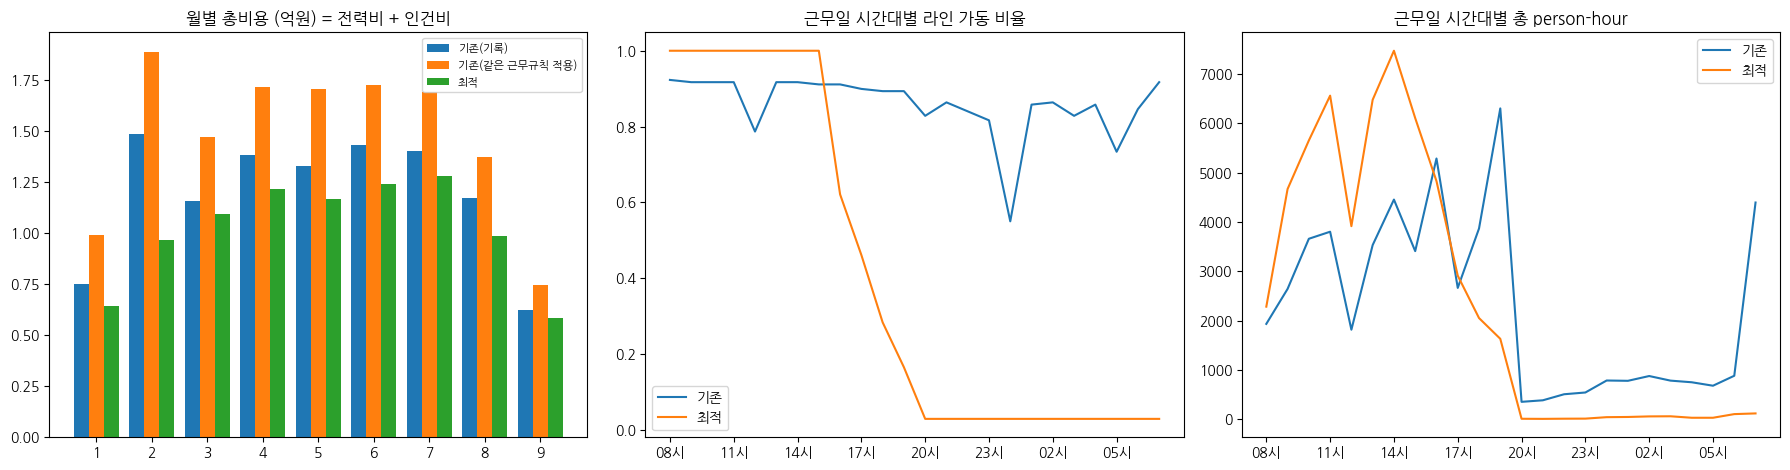

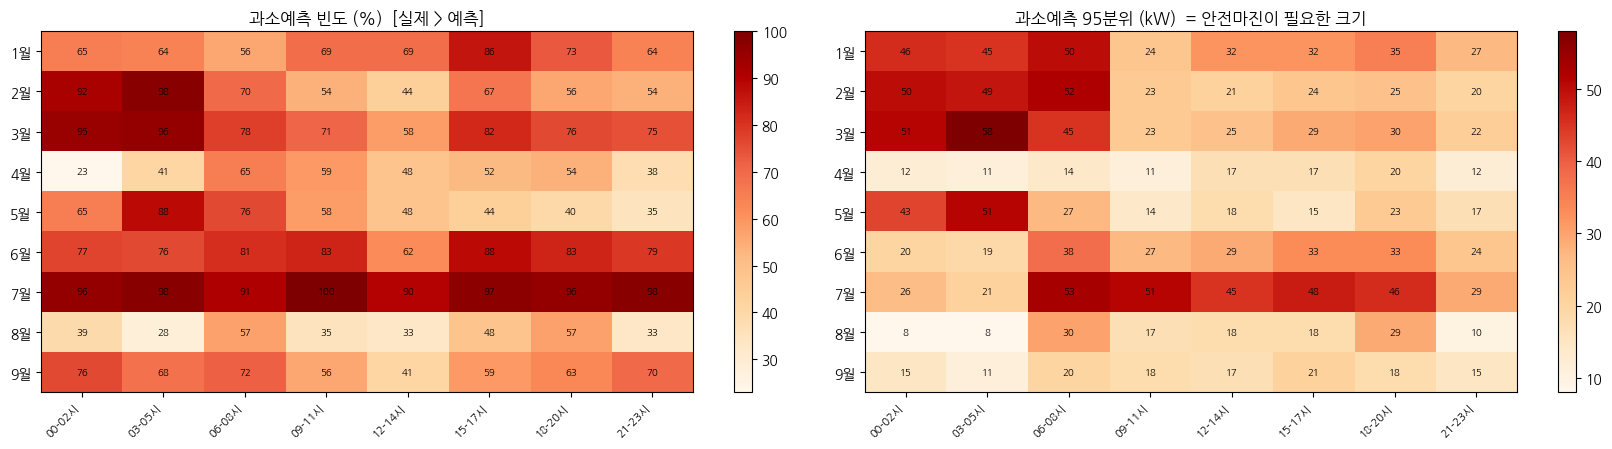

In [9]:
# ============================================================
# 시각화: 월별 총비용 / 시간대별 라인 가동 비율 / 시간대별 person-hour
# ============================================================
import matplotlib.pyplot as plt, os
try:
    import matplotlib.font_manager as fm, urllib.request
    fp = "NanumGothic.ttf"
    if not os.path.exists(fp): urllib.request.urlretrieve("https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf", fp)
    fm.fontManager.addfont(fp); plt.rcParams["font.family"] = fm.FontProperties(fname=fp).get_name()
except Exception as _e:
    print("한글 폰트 설정 생략:", _e)
plt.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8)); mm = REPORT.drop(index="합계"); xx = np.arange(len(mm)); wd = 0.27
ax[0].bar(xx - wd, mm["기존 총비용(원)"] / 1e8, wd, label="기존(기록)"); ax[0].bar(xx, (mm["[공정비교] 규칙적용 기존 인건비(원)"] + mm["기존 전력비(원)"]) / 1e8, wd, label="기존(같은 근무규칙 적용)"); ax[0].bar(xx + wd, mm["최적 총비용(원)"] / 1e8, wd, label="최적")
ax[0].set_xticks(xx); ax[0].set_xticklabels(mm.index); ax[0].set_title("월별 총비용 (억원) = 전력비 + 인건비"); ax[0].legend(fontsize=8)
dd = res[res["최적화대상"] == 1]; order = [(LINE_START_HOUR + j) % 24 for j in range(24)]; hh = dd.groupby("시")[["기존가동", "최적가동"]].mean().reindex(order)
ax[1].plot(range(24), hh["기존가동"].values, label="기존"); ax[1].plot(range(24), hh["최적가동"].values, label="최적"); ax[1].set_title("근무일 시간대별 라인 가동 비율"); ax[1].legend()
pp = dd.groupby("시")[["기존인원", "최적인원"]].sum().reindex(order); ax[2].plot(range(24), pp["기존인원"].values, label="기존"); ax[2].plot(range(24), pp["최적인원"].values, label="최적"); ax[2].set_title("근무일 시간대별 총 person-hour"); ax[2].legend()
for a_ in ax[1:]: a_.set_xticks(range(0, 24, 3)); a_.set_xticklabels([f"{order[j]:02d}시" for j in range(0, 24, 3)])
plt.tight_layout(); plt.show()

# ---- 과소예측 지도: 달 x 3시간 구간 (가동 상태 Peak) ----
fig, ax = plt.subplots(1, 2, figsize=(17, 4.6))
for a_, tab, ttl, cm in [(ax[0], UND_FREQ, "과소예측 빈도 (%)  [실제 > 예측]", "OrRd"), (ax[1], UND_Q95, "과소예측 95분위 (kW)  = 안전마진이 필요한 크기", "OrRd")]:
    im = a_.imshow(tab.values, aspect="auto", cmap=cm); a_.set_xticks(range(tab.shape[1])); a_.set_xticklabels(tab.columns, rotation=45, ha="right", fontsize=8)
    a_.set_yticks(range(tab.shape[0])); a_.set_yticklabels([f"{m}월" for m in tab.index]); a_.set_title(ttl); plt.colorbar(im, ax=a_)
    for i in range(tab.shape[0]):
        for j in range(tab.shape[1]): a_.text(j, i, "" if np.isnan(tab.values[i, j]) else int(tab.values[i, j]), ha="center", va="center", fontsize=7)
plt.tight_layout(); plt.show()

## 8. 1~9월 인원 배치표 엑셀 출력
`인원배치표_1-9월.xlsx` — 읽는 법 / 월별 요약 / 일별 근무배치(전체) / 월별 근무배치 / 일별 시간별 투입 인원 / 기존 유지일(주말 · 휴무)

In [10]:
# ============================================================
# 1~9월 인원 배치표 엑셀 출력  ->  ROSTER_PATH
#  시트: 읽는 법 / 월별 요약 / 일별 근무배치(전체) / 1월~9월(월별 근무배치) / 일별 시간별 투입 인원 / 기존 유지일(주말·휴무)
# ============================================================
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter
_wd = "월화수목금토일"
_days = DAYS.assign(근무일=pd.to_datetime(DAYS["근무일"]))
ROSTER = PLANS.drop(columns=["_a", "_seq"], errors="ignore").copy(); ROSTER["근무일"] = pd.to_datetime(ROSTER["근무일"])
ROSTER = ROSTER.merge(_days[["근무일", "최적가동시간", "라인종료시각", "고용인원(명)"]], on="근무일", how="left")
ROSTER["요일"] = ROSTER["근무일"].dt.dayofweek.map(lambda d: _wd[d]); ROSTER["월"] = ROSTER["근무일"].dt.month
ROSTER["라인 가동"] = "08:00 ~ " + ROSTER["라인종료시각"].astype(str); ROSTER["구분"] = np.where(ROSTER["실근로시간"] < LONG_SHIFT_MIN, "단기(5시간 미만)", "5시간 이상")
ROSTER = ROSTER.rename(columns={"무급 휴게": "무급 휴게 시각", "근무형태": "근무형태 코드", "고용인원(명)": "그날 총 고용(명)"}).sort_values(["근무일", "출근", "퇴근", "실근로시간"])
ROSTER["근무일"] = ROSTER["근무일"].dt.strftime("%Y-%m-%d")
COLS = ["근무일", "요일", "라인 가동", "출근", "퇴근", "실근로시간", "체류시간", "무급 휴게 시각", "근무형태 코드", "구분", "인원(명)", "그날 총 고용(명)"]
# 월별 요약
_p = PLANS.assign(월=pd.to_datetime(PLANS["근무일"]).dt.month, wh=PLANS["실근로시간"] * PLANS["인원(명)"]); _d = _days.assign(월=_days["근무일"].dt.month)
SUMM = pd.DataFrame({"근무일수": _d.groupby("월").size(), "고용 인원(명-일)": _p.groupby("월")["인원(명)"].sum(), "일 평균 고용(명)": _d.groupby("월")["고용인원(명)"].mean(), "평균 가동시간(h)": _d.groupby("월")["최적가동시간"].mean(),
    "평균 실근로시간(h)": _p.groupby("월")["wh"].sum() / _p.groupby("월")["인원(명)"].sum(), "단기(5h 미만) 비율(%)": _p[_p["실근로시간"] < LONG_SHIFT_MIN].groupby("월")["인원(명)"].sum() / _p.groupby("월")["인원(명)"].sum() * 100,
    "휴게 있는 근무자 비율(%)": _p[_p["휴게(시간)"] > 0].groupby("월")["인원(명)"].sum() / _p.groupby("월")["인원(명)"].sum() * 100,
    "근로 person-hour": _d.groupby("월")["최적person-hour"].sum(), "계획 인건비(원)": _d.groupby("월")["최적인건비"].sum(), "계획 생산량": _d.groupby("월")["최적생산량"].sum()}).fillna(0).round(1)
SUMM.loc["합계"] = [SUMM["근무일수"].sum(), SUMM["고용 인원(명-일)"].sum(), _d["고용인원(명)"].mean(), _d["최적가동시간"].mean(), _p["wh"].sum() / _p["인원(명)"].sum(), _p[_p["실근로시간"] < LONG_SHIFT_MIN]["인원(명)"].sum() / _p["인원(명)"].sum() * 100,
                    _p[_p["휴게(시간)"] > 0]["인원(명)"].sum() / _p["인원(명)"].sum() * 100, SUMM["근로 person-hour"].sum(), SUMM["계획 인건비(원)"].sum(), SUMM["계획 생산량"].sum()]
SUMM = SUMM.round(1); SUMM.index = [f"{m}월" if m != "합계" else "합계" for m in SUMM.index]
# 일별 x 시간별 투입 인원 (08시~다음날 07시 근무일 기준)
_r = res.copy(); _r["근무일"] = pd.to_datetime(_r["근무일"]); _r["off"] = (_r["시"] - 8) % 24
HOURLY = _r.pivot_table(index="근무일", columns="off", values="최적인원", aggfunc="sum").round(1); HOURLY.columns = [f"{(8 + int(c)) % 24:02d}시" for c in HOURLY.columns]
HOURLY.insert(0, "요일", [_wd[d.dayofweek] for d in HOURLY.index]); HOURLY.insert(1, "구분", np.where(_r.groupby("근무일")["최적화대상"].max().reindex(HOURLY.index) == 1, "최적화 근무일", "기존 유지(주말·휴무 등)"))
HOURLY["합계(person-hour)"] = HOURLY.drop(columns=["요일", "구분"]).sum(axis=1).round(1); HOURLY.index = HOURLY.index.strftime("%Y-%m-%d"); HOURLY.index.name = "근무일(08시 시작)"
FIXED = _r[_r["최적화대상"] == 0].groupby("근무일").agg(기존생산량=("기존생산량", "sum"), 기존_person_hour=("기존인원", "sum")).reset_index(); FIXED = FIXED[(FIXED["기존생산량"] > 0) | (FIXED["기존_person_hour"] > 0)]
FIXED.insert(1, "요일", FIXED["근무일"].dt.dayofweek.map(lambda d: _wd[d])); FIXED["근무일"] = FIXED["근무일"].dt.strftime("%Y-%m-%d"); FIXED["비고"] = "기존 값 유지(주말·휴무·데이터 가장자리). 시간별 인원은 '일별_시간별_투입인원' 시트 참고"; FIXED = FIXED.round(1)
GUIDE = pd.DataFrame({"읽는 법": ["● 근무일은 08시에 시작해 다음날 07시에 끝나는 24시간입니다. 라인은 08시에 가동을 시작하고, 생산을 다 채우면 종료합니다(중간 정지 없음).",
    "● 근무형태 코드: W = 1시간 근무, H = 30분 근무(마지막 시간), B = 무급 휴게 1시간. 코드의 첫 글자가 출근 시각의 1시간입니다.",
    "● 실근로시간: 2·3·4시간(단기, 쉬지 않고 근무) / 5시간 이상은 30분 단위. 5~8시간 근무는 휴게 1시간, 8.5시간 이상은 휴게 2시간.",
    f"● 단기(5시간 미만) 근무자는 하루 고용 인원의 {int(MAX_SHORT_SHIFT_SHARE*100) if MAX_SHORT_SHIFT_SHARE else '제한 없음'}% 미만으로 제한했습니다." if MAX_SHORT_SHIFT_SHARE else "● 단기 근무자 비율 제한 없음.",
    "● '일별_시간별_투입인원'은 시간별로 실제 일하는 인원(휴게 중인 인원 제외, 30분 근무는 0.5)입니다.",
    "● 주말·휴무일 등 최적화하지 않은 날은 기존 값을 유지하며 '기존유지일' 시트와 시간별 시트에서 확인합니다.",
    "● 인건비는 무급 휴게를 제외한 근로시간 x 시급(9~17시 1.0배, 그 외 1.5배)입니다."]})
with pd.ExcelWriter(ROSTER_PATH, engine="openpyxl") as w:
    GUIDE.to_excel(w, sheet_name="읽는 법", index=False); SUMM.to_excel(w, sheet_name="월별 요약", index_label="월")
    ROSTER[COLS].to_excel(w, sheet_name="일별 근무배치(전체)", index=False)
    for m in sorted(ROSTER["월"].unique()): ROSTER[ROSTER["월"] == m][COLS].to_excel(w, sheet_name=f"{int(m)}월 근무배치", index=False)
    HOURLY.to_excel(w, sheet_name="일별_시간별_투입인원"); FIXED.to_excel(w, sheet_name="기존유지일(주말·휴무)", index=False)
    for ws in w.book.worksheets:
        ws.freeze_panes = "A2"
        for c in ws[1]: c.font = Font(bold=True); c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=(ws.title == "읽는 법"))
        for col in ws.columns:
            L = max((len(str(c.value)) if c.value is not None else 0) for c in col[:300]); ws.column_dimensions[get_column_letter(col[0].column)].width = min(max(8, L * 1.7 + 2), 120 if ws.title == "읽는 법" else 42)
print(f"인원 배치표 저장: {ROSTER_PATH} | 근무일 {len(_days)}일 | 배치 행 {len(ROSTER):,}개 | 총 고용 {int(ROSTER['인원(명)'].sum()):,}명-일 | 시트 {len(w.book.worksheets) if hasattr(w, 'book') else ''}개")

인원 배치표 저장: 인원배치표_1-9월.xlsx | 근무일 169일 | 배치 행 1,483개 | 총 고용 13,412명-일 | 시트 14개


## 9. 하루 목표 생산량별 인원 배치 (1월 · 4월 · 7월 대표일)
각 월의 대표일(근무일 중 일 생산량이 월 중앙값에 가장 가까운 날, 실제 날씨 사용)에 대해
하루 목표 생산량 **10,000 / 15,000 / 20,000 / 25,000개**의 라인 운영과 근무 배치를 같은 모델 · 같은 제약으로 구한다.
결과는 `하루목표별_인원배치.xlsx`에 저장한다.

In [11]:
# ============================================================
# 하루 목표 생산량별 인원 배치
#  근무일 1월·4월·7월에서 대표일(월 중앙값에 가장 가까운 생산일, 실제 날씨 사용)을 고르고,
#  하루 목표 생산량이 10,000 / 15,000 / 20,000 / 25,000개일 때 라인 운영과 일용직 근무 배치를 같은 모델·같은 제약으로 구한다.
#   - 시간별 생산 기준(p_ref) = 목표 x 그 달 근무일의 평균 시간대별 생산 비중, 상한/하한·월별 낮 생산 상향 규칙·안전마진 동일
#   - 08시 가동 시작 -> 연속 가동 -> 목표를 채우면 라인 종료, 정수 근무패턴(휴게·단기 근무자 비율)으로 배치
# ============================================================
from openpyxl.styles import Font, Alignment
DAY_TARGETS = [10000, 15000, 20000, 25000]; DAY_MONTHS = [1, 4, 7]; DAY_ROSTER_PATH = "하루목표별_인원배치.xlsx"
_bm = np.array([int(df["month"].iloc[b[0]]) for b in BLOCKS]); _bq = np.array([p0[b].sum() for b in BLOCKS])
_clock = np.array([(LINE_START_HOUR + j) % 24 for j in range(24)])

def month_shape(month):
    """그 달 근무일의 평균 시간대별 생산 비중 (08시 기준 24시간, 합 = 1)"""
    ks = [k for k in range(D) if _bm[k] == month]
    if not ks: ks = [k for k in range(D) if _bm[k] == min(_bm, key=lambda m_: abs(m_ - month))]
    sh = np.mean([p0[BLOCKS[k]] / max(p0[BLOCKS[k]].sum(), 1) for k in ks], axis=0); return sh / sh.sum()

def day_arrays_from_block(kk, month):
    """실제 근무일(블록 kk)의 날씨·예측 배열 (08시 시작 24시간)"""
    b = BLOCKS[kk]
    return dict(PON=PON[b], POFF=POFF[b], EON=EON[b], EOFF=EOFF[b], rho=rho_hat[b], tariff=tariff[b], heat=heat_risk[b], wlim=wlim[b], riskw=risk_w[b], wage=wage[b], shape=month_shape(month))

def solve_day_A(A, Q, month):
    """하루 목표 생산량 Q 를 채우는 최소비용 라인 운영 + 정수 근무 배치 (A: 24시간 배열 모음)"""
    shape = A["shape"]; pref = Q * shape; cap_obs = float(np.quantile(p0[p0 > 0], BOOST_CAP_QUANTILE)); qhi = MAX_PRODUCTION_RATIO * pref
    for ms, (h0, h1), rr in BOOST_RULES:
        if month in ms: sel = (_clock >= h0) & (_clock <= h1); qhi[sel] = np.maximum(qhi[sel], np.minimum(rr * pref[sel], cap_obs))
    qlo = MIN_PRODUCTION_RATIO * pref
    PONd, POFFd, EOFFd = A["PON"], A["POFF"], A["EOFF"]
    cuP_d = PONd - POFFd - bq * pref; cuE_d = A["EON"] - EOFFd - gq * pref; rho = A["rho"]; tar = A["tariff"]; hr = A["heat"]; wl = A["wlim"]; rw = A["riskw"]; NM = 2000.0
    iq, in_, iu, ip, ie, iz = np.arange(24), 24 + np.arange(24), 48 + np.arange(24), 72 + np.arange(24), 96 + np.arange(24), 120; nv = 121
    rows, lo, hi = [], [], []
    def add(cols, vals, l=-np.inf, h=np.inf):
        r = np.zeros(nv); r[cols] = vals; rows.append(r); lo.append(l); hi.append(h)
    add(iu, np.ones(24), MIN_LINE_HOURS)
    for j in range(23): add([iu[j + 1], iu[j]], [1, -1], h=0)
    for j in range(24):
        add([in_[j], iu[j]], [1, -NM], h=0); add([iq[j], iu[j]], [1, -qhi[j]], h=0); add([iq[j], iu[j]], [1, -qlo[j]], l=0); add([iq[j], in_[j]], [1, -rho[j]], h=0)
        add([ip[j], iq[j], iu[j]], [1, -bq, -cuP_d[j]], POFFd[j], POFFd[j]); add([iz, ip[j]], [1, -1], l=0); add([ie[j], ip[j]], [1, -1], l=-wl[j])
    add(iq, np.ones(24), l=Q)                                                       # 하루 목표 생산량
    A_ = np.array(rows); lb = np.zeros(nv); ub = np.full(nv, np.inf); ub[iq] = qhi; ub[in_] = NM; ub[iu] = 1; lb[iu[0]] = 1; integ = np.zeros(nv); integ[iu] = 1
    def run(c, ubz=None):
        u_ = ub.copy()
        if ubz is not None: u_[iz] = ubz
        return milp(c, constraints=LinearConstraint(A_, np.array(lo), np.array(hi)), integrality=integ, bounds=Bounds(lb, u_), options=dict(time_limit=60, mip_rel_gap=0.002))
    c1 = np.zeros(nv); c1[iz] = 1; r1 = run(c1)
    if r1.x is None: raise RuntimeError(f"{month}월 목표 {Q:,.0f}개: 실행 가능한 계획이 없습니다 (시간당 생산 상한으로 목표를 채울 수 없음)")
    zstar = r1.x[iz]; price = A["wage"].copy(); best = None
    for it in range(3):
        c2 = np.zeros(nv); c2[iq] = tar * gq; c2[iu] = tar * cuE_d; c2[in_] = price; c2[ip] = HEAT_PEAK_PENALTY * hr; c2[ie] = PEAK_LIMIT_PENALTY * rw
        r2 = run(c2, zstar + 1e-6); qd, ud = r2.x[iq], np.round(r2.x[iu]); need = np.where(ud > .5, qd / rho, 0.0)
        x_, pi_ = staff_day(need, ud); nint = COV.T @ x_; lab = float((HC.T @ x_).sum()); Ed = EOFFd + cuE_d * ud + gq * qd; en = float((tar * Ed).sum())
        if best is None or lab + en < best["lab"] + best["en"]: best = dict(q=qd, u=ud, x=x_, n=nint, lab=lab, en=en, E=Ed, P=POFFd + cuP_d * ud + bq * qd, pref=pref, qhi=qhi)
        price = np.where(pi_ > 0, 0.5 * price + 0.5 * pi_, price)
    return best

def solve_day(bi, Q, month):
    return solve_day_A(day_arrays_from_block(bi, month), Q, month), None

CASES, ROST, HOURLY_D, DAYINFO = [], [], [], []
for m in DAY_MONTHS:
    ks = np.where(_bm == m)[0]; kk = ks[np.argmin(np.abs(_bq[ks] - np.median(_bq[ks])))]; b = BLOCKS[kk]
    DAYINFO.append({"월": m, "대표일": df["sday"].iloc[b[0]].strftime("%Y-%m-%d"), "요일": "월화수목금토일"[int(df["sday_dow"].iloc[b[0]])], "평균기온(℃)": round(float(df["기온"].values[b].mean()), 1), "최고기온(℃)": round(float(df["기온"].values[b].max()), 1),
                    "평균풍속(m/s)": round(float(df["풍속"].values[b].mean()), 2), "평균습도(%)": round(float(df["습도"].values[b].mean()), 1), "기존 일 생산량": round(float(p0[b].sum())), "기존 가동시간(h)": int((p0[b] > 0).sum())})
    for Q in DAY_TARGETS:
        res_, pref = solve_day(kk, float(Q), m); on_h = int(res_["u"].sum()); end_h = (LINE_START_HOUR + on_h) % 24; x_ = res_["x"]
        tot = x_.sum(); wk = sum(PAT[i][3] * x_[i] for i in np.where(x_ > .5)[0]); short = x_[IS_SHORT].sum()
        CASES.append({"월": m, "대표일": DAYINFO[-1]["대표일"], "하루 목표 생산량": Q, "계획 생산량": round(float(res_["q"].sum())), "라인 가동": f"08:00 ~ {end_h:02d}:00" if on_h < 24 else "08:00 ~ 다음날 08:00", "가동시간(h)": on_h, "고용 인원(명)": int(tot), "단기(5h 미만) 비율(%)": round(short / tot * 100, 1),
                      "평균 실근로(h)": round(wk / tot, 2), "총 근로 person-hour": round(float(res_["n"].sum()), 1), "인건비(원)": round(res_["lab"]), "전력량(kWh)": round(float(res_["E"].sum())), "전력비(원)": round(res_["en"]), "총비용(원)": round(res_["lab"] + res_["en"]),
                      "최대 전력 Peak(kW, 예측+마진)": round(float(res_["P"].max()), 1), "1인당 생산량(개/인)": round(float(res_["q"].sum() / tot))})
        HOURLY_D.append({"월": m, "하루 목표 생산량": Q, **{f"{h:02d}시": round(float(v), 1) for h, v in zip(_clock, res_["n"])}})
        for i in np.where(x_ > .5)[0]:
            a, span, seq, W = PAT[i]; sh = (LINE_START_HOUR + a) % 24; half = seq[-1] == "H"; e_ = sh + span - (0.5 if half else 0.0); brk = [(sh + j) % 24 for j, c in enumerate(seq) if c == "B"]
            ROST.append({"월": m, "하루 목표 생산량": Q, "출근": f"{sh:02d}:00", "퇴근": f"{int(e_) % 24:02d}:{'30' if e_ % 1 else '00'}", "실근로시간": W, "무급 휴게 시각": ", ".join(f"{h:02d}시" for h in brk) if brk else "없음", "근무형태 코드": "".join(seq), "구분": "단기(5시간 미만)" if W < LONG_SHIFT_MIN else "5시간 이상", "인원(명)": int(x_[i])})
DAY_SUM, DAY_HOURLY, DAY_ROST, DAY_INFO = pd.DataFrame(CASES), pd.DataFrame(HOURLY_D), pd.DataFrame(ROST).sort_values(["월", "하루 목표 생산량", "출근", "퇴근"]), pd.DataFrame(DAYINFO)
with pd.ExcelWriter(DAY_ROSTER_PATH, engine="openpyxl") as w:
    DAY_SUM.to_excel(w, sheet_name="요약(12세트)", index=False); DAY_HOURLY.to_excel(w, sheet_name="시간별 투입 인원", index=False); DAY_ROST.to_excel(w, sheet_name="근무배치 상세", index=False); DAY_INFO.to_excel(w, sheet_name="대표일 정보", index=False)
    for ws in w.book.worksheets:
        ws.freeze_panes = "A2"
        for c in ws[1]: c.font = Font(bold=True); c.alignment = Alignment(horizontal="center", vertical="center")
        for col in ws.columns: ws.column_dimensions[col[0].column_letter].width = min(max(8, max((len(str(c.value)) if c.value is not None else 0) for c in col[:200]) * 1.7 + 2), 40)
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
print("[대표일]"); print(DAY_INFO.to_string(index=False)); print("\n[하루 목표 생산량별 인원 배치 요약]")
print(DAY_SUM[["월", "하루 목표 생산량", "계획 생산량", "라인 가동", "고용 인원(명)", "단기(5h 미만) 비율(%)", "평균 실근로(h)", "인건비(원)", "전력비(원)", "총비용(원)", "최대 전력 Peak(kW, 예측+마진)"]].to_string(index=False)); print("저장 완료:", DAY_ROSTER_PATH)

[대표일]
 월        대표일 요일  평균기온(℃)  최고기온(℃)  평균풍속(m/s)  평균습도(%)  기존 일 생산량  기존 가동시간(h)
 1 2021-01-25  월      8.7     10.7       2.28     73.7     14441          15
 4 2021-04-12  월     14.7     17.0       2.46     95.1     16990          19
 7 2021-07-01  목     23.1     27.3       2.08     80.8     18936          23

[하루 목표 생산량별 인원 배치 요약]
 월  하루 목표 생산량  계획 생산량         라인 가동  고용 인원(명)  단기(5h 미만) 비율(%)  평균 실근로(h)  인건비(원)  전력비(원)  총비용(원)  최대 전력 Peak(kW, 예측+마진)
 1      10000   10000 08:00 ~ 21:00        41             48.8       4.60 2221380 1238882 3460262                  205.5
 1      15000   15000 08:00 ~ 21:00        61             49.2       4.59 3302400 1239367 4541767                  205.5
 1      20000   20000 08:00 ~ 21:00        81             49.4       4.57 4367940 1239852 5607792                  205.4
 1      25000   25000 08:00 ~ 21:00        99             49.5       4.69 5474760 1240337 6715097                  205.4
 4      10000   10000 08:00 ~ 19:00        39             

## 10. 하루 계획 도구 — 월 · 생산량 · 강수 유무 → 최적 인원 배치
`DAY_MONTH`, `DAY_TARGET`, `DAY_RAIN` 세 값만 바꿔 실행한다.
1. **기상 예측**: `WEATHER_FN(month, rain)`이 있으면 사용 (예: 기상 LSTM), 없으면 같은 달 · 같은 강수 유무의 기후 유사일 평균
2. 예측한 날씨로 전력 · 1인당 생산량 · 안전마진 계산
3. 같은 모델 · 같은 제약으로 라인 운영과 정수 근무 배치를 구해 표와 그래프로 출력 (`DAY_SAVE = True`면 엑셀 · PNG 저장)

> 보강+보정 LSTM은 직전 24시간 실측 전력이 입력이라 미래 하루 계획에는 쓸 수 없으므로, 이 셀은 날씨 기반 ML 예측을 사용한다.


===== 4월 · 하루 20,000개 · 비 없음 · 최적 인원 배치 =====
                    항목                                                 값
0                   입력                            4월 · 하루 20,000개 · 비 없음
1             기상 예측 방법  기후 유사일 5일 평균 (04-01, 04-02, 04-16, 04-25, 04-27)
2                라인 가동                              08:00 ~ 19:00 (11시간)
3                고용 인원                                               76명
4        단기(5시간 미만) 비율                                             47.4%
5             평균 실근로시간                                            4.64시간
6                  인건비                                             379만원
7                  전력비                                             168만원
8                  총비용                                             548만원
9   예상 최대 Peak (예측+마진)                                             190kW
10             안전마진 배율                                            x 0.85

[근무 배치표]  (코드: W 근무 1시간, H 근무 30분, B 무급 휴게 1시간)
       출근     퇴근  실근로시간  무급 

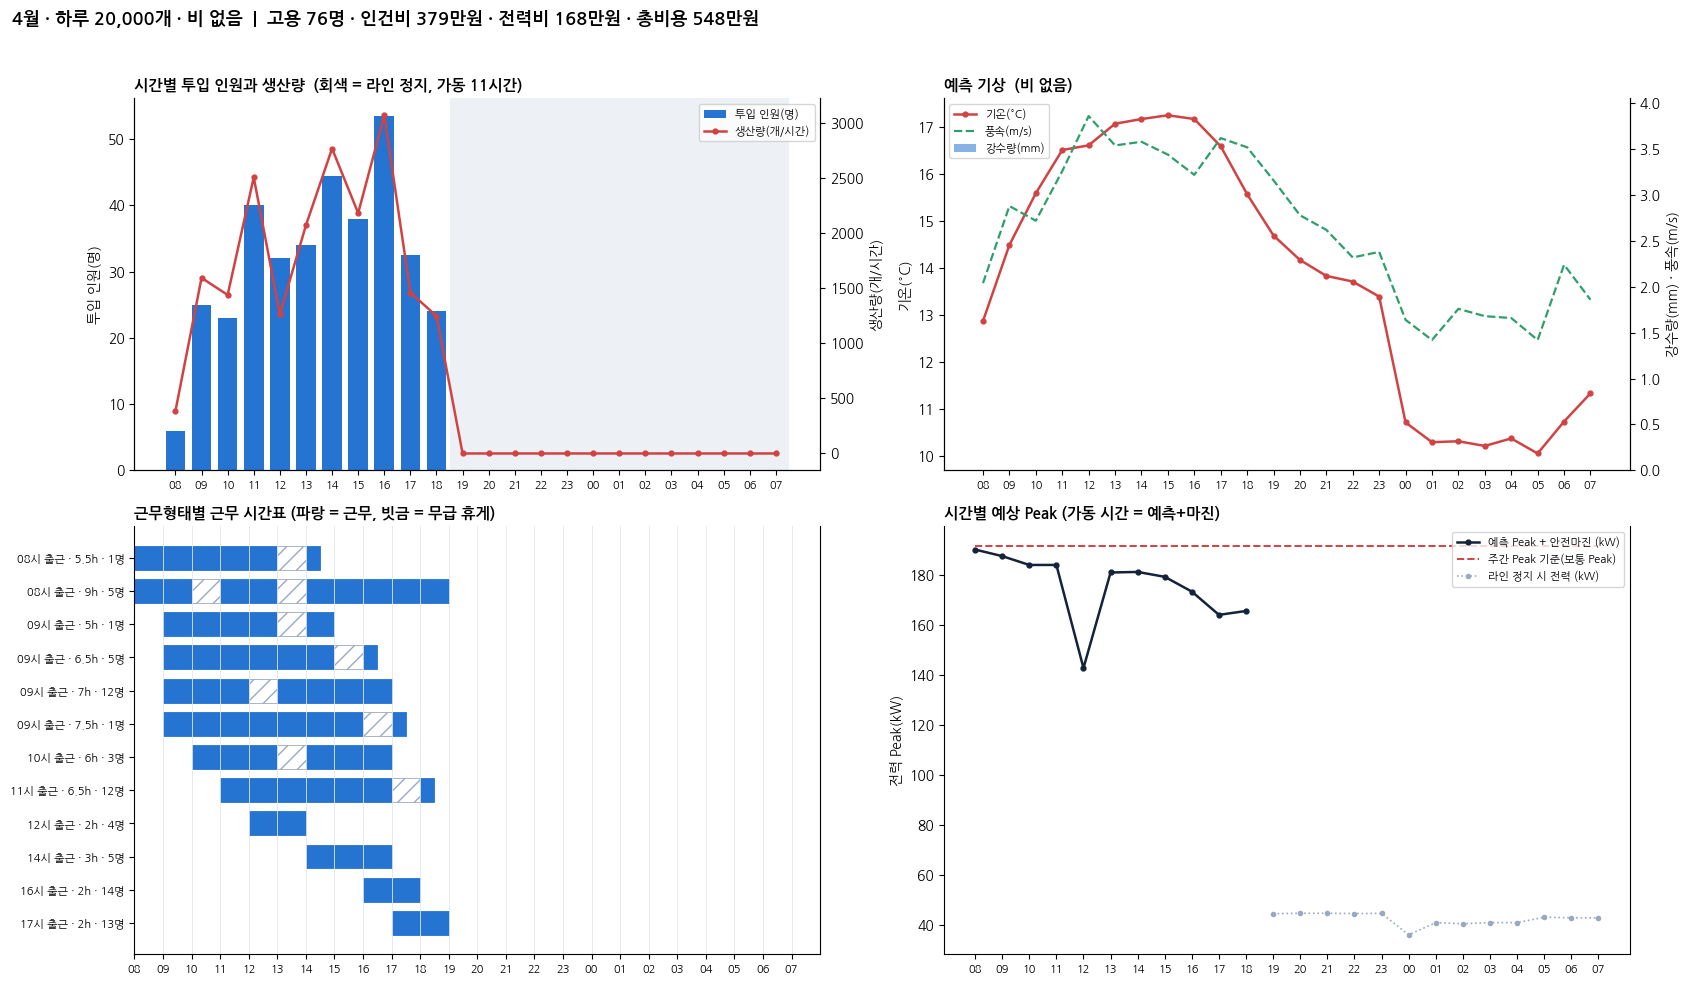

In [13]:
# ============================================================
# 원하는 월 · 하루 생산량 · 강수 유무를 넣으면 -> 그 날의 기상을 예측하고 -> 최적 인원 배치를 표와 그래프로 보여줌
#  1) 기상 예측: WEATHER_FN(month, rain) 이 있으면 그것(예: 기상 LSTM)을 쓰고, 없으면 같은 달·같은 강수 유무의 비슷한 날 평균(기후 유사일)을 쓴다
#  2) 예측한 날씨로 가동·무가동 전력(Peak·전력량), 1인당 생산량(ML), 안전마진을 계산 (기존 ML 모델 · 시간대×달 차등 마진 x MARGIN_SCALE)
#  3) 같은 모델·같은 제약으로 라인 운영(08시 시작, 목표를 채우면 종료)과 정수 근무 배치를 구한다
#  ※ 보강+보정 LSTM 은 직전 24시간 실측 전력이 입력이라 미래 하루 계획에는 쓸 수 없어, 이 셀은 날씨 기반 ML 예측을 사용한다.
# ============================================================
DAY_MONTH, DAY_TARGET, DAY_RAIN = 4, 20000, False     # <- 여기 세 값만 바꿔서 실행 (월 1~9, 하루 생산량(개), 비 오는 날이면 True)
WEATHER_FN = None      # 기상 예측 LSTM 을 연결하려면: def my_weather(month, rain) -> DataFrame(24행, 컬럼 ['시','기온','습도','풍속','강수량']) 를 만들어 WEATHER_FN = my_weather
DAY_SAVE = True
import matplotlib.pyplot as plt
from openpyxl.styles import Font as _F2, Alignment as _A2
try:
    import matplotlib.font_manager as fm, urllib.request
    _fp = "NanumGothic.ttf"
    if not os.path.exists(_fp): urllib.request.urlretrieve("https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf", _fp)
    fm.fontManager.addfont(_fp); plt.rcParams["font.family"] = fm.FontProperties(fname=_fp).get_name()
except Exception as _e:
    _cj = [f.name for f in fm.fontManager.ttflist if any(k in f.name for k in ["Malgun", "AppleGothic", "Nanum", "Noto Sans CJK"])]
    if _cj: plt.rcParams["font.family"] = _cj[0]
plt.rcParams["axes.unicode_minus"] = False
_show = (lambda x: display(x)) if "display" in globals() else (lambda x: print(x.to_string()))

def climatology_weather(month, rain, k=5):
    """같은 달(부족하면 인접 달, 기온 보정)·같은 강수 유무인 날 중 월 평균 기온에 가장 가까운 k일의 시간대별 평균"""
    d_ = df[["datetime", "month", "hour", "기온", "습도", "풍속", "강수량"]].copy(); d_["date"] = d_["datetime"].dt.date
    day = d_.groupby("date").agg(month=("month", "first"), n=("hour", "size"), t=("기온", "mean"), rain=("강수량", lambda s: bool((s > 0).any())))
    day = day[day["n"] == 24]; mt = d_.groupby("month")["기온"].mean(); target_t = float(mt.get(month, mt.iloc[(mt.index - month).map(abs).argmin()]))
    pool = day[(day["rain"] == bool(rain)) & (day["month"] == month)]
    if len(pool) < 3: pool = day[(day["rain"] == bool(rain)) & (day["month"].isin([month - 1, month, month + 1]))]
    if len(pool) < 3: pool = day[day["rain"] == bool(rain)]
    pool = pool.assign(gap=(pool["t"] - target_t).abs()).sort_values("gap").head(k); sel = d_[d_["date"].isin(pool.index)].copy()
    sel["기온"] = sel["기온"] + (target_t - sel["month"].map(mt)) * (sel["month"] != month)                  # 다른 달 날은 월 평균 기온 차이만큼 보정
    W = sel.groupby("hour")[["기온", "습도", "풍속", "강수량"]].mean().reindex(range(24)).interpolate(limit_direction="both").reset_index().rename(columns={"hour": "시"})
    if not rain: W["강수량"] = 0.0
    return W, f"기후 유사일 {len(pool)}일 평균 ({', '.join(str(x)[5:] for x in sorted(pool.index))})"

def day_arrays_from_weather(month, W):
    """예측한 24시간 날씨 -> 08시 시작 기준 24시간 전력·생산성·마진 배열"""
    Wj = W.set_index("시").reindex(_clock).reset_index(); F = pd.DataFrame({"hour": _clock, "dow": 1, "month": month, "기온": Wj["기온"].values, "습도": Wj["습도"].values, "풍속": Wj["풍속"].values, "강수량": Wj["강수량"].values})
    F_on = F.copy(); F_on["since"] = np.minimum(np.arange(24) + 1, 3)                                             # 08시 가동 시작 후 경과시간 (최대 3)
    Pon, Eon = MOD[("on", "P")]["predict"](F_on), MOD[("on", "E")]["predict"](F_on); Poff, Eoff = MOD[("off", "P")]["predict"](F[F_BASE]), MOD[("off", "E")]["predict"](F[F_BASE])
    (aP, bP), (aE, bE) = MSURF["P"], MSURF["E"]; mP = np.array([aP[h] * bP.get(month, 1.0) for h in _clock]) * MARGIN_SCALE; mE = np.array([aE[h] * bE.get(month, 1.0) for h in _clock]) * MARGIN_SCALE
    SP, SE = np.minimum(Pon + mP, CAP[("on", "P")]), np.minimum(Eon + mE, CAP[("on", "E")]); SoP, SoE = np.minimum(Poff + mOffP[0], CAP[("off", "P")]), np.minimum(Eoff + mOffE[0], CAP[("off", "E")])
    PRd = F[F_BASE].copy(); PRd["since"] = F_on["since"].values; PRd["E_in"] = Eon; rho = np.maximum(_pq(PRd), 0.25 * prod_tr["rho"].median())
    tmask = (df["month"].values == month) & dec; tmask = tmask if tmask.any() else dec
    Tm_, RH_ = Wj["기온"].values, Wj["습도"].values; heat = np.where(Tm_ >= HEAT_TEMP, np.minimum(1.0, 0.5 + 0.5 * (Tm_ - HEAT_TEMP) / (HEAT_TEMP_FULL - HEAT_TEMP)), 0.0) * np.where(RH_ >= HEAT_HUMID, 1.0, HEAT_ONLY_WEIGHT)
    wl = float(np.median(wlim[tmask])); riskw = 1.0 + RISK_GAIN * np.maximum(0.0, (SP - wl) / wl)
    A = dict(PON=SP, POFF=SoP, EON=SE, EOFF=SoE, rho=rho, tariff=np.full(24, float(df.loc[df["month"] == month, "tariff"].iloc[0])), heat=heat, wlim=np.full(24, wl), riskw=riskw, wage=np.array([HOURLY_WAGE * wage_multiplier(h) for h in _clock]), shape=month_shape(month))
    return A, Wj

def plan_day(month, target, rain, weather_fn=None):
    assert 1 <= month <= 9, "월은 1~9 (학습 데이터 기간)만 지원합니다"
    if weather_fn is not None: W = weather_fn(month, rain).copy(); src = "사용자 기상 예측 모델(WEATHER_FN)"
    else: W, src = climatology_weather(month, rain)
    A, Wj = day_arrays_from_weather(month, W); res_ = solve_day_A(A, float(target), month)
    return res_, A, Wj, src

def show_day_plan(month, target, rain, res_, A, Wj, src):
    on_h = int(res_["u"].sum()); end_h = (LINE_START_HOUR + on_h) % 24; x_ = res_["x"]; idx = np.where(x_ > .5)[0]; tot = int(x_.sum()); short = float(x_[IS_SHORT].sum() / tot * 100); wk = sum(PAT[i][3] * x_[i] for i in idx)
    SUMMARY = pd.DataFrame({"항목": ["입력", "기상 예측 방법", "라인 가동", "고용 인원", "단기(5시간 미만) 비율", "평균 실근로시간", "인건비", "전력비", "총비용", "예상 최대 Peak (예측+마진)", "안전마진 배율"],
        "값": [f"{month}월 · 하루 {target:,.0f}개 · {'비 오는 날' if rain else '비 없음'}", src, f"08:00 ~ {end_h:02d}:00 ({on_h}시간)", f"{tot}명", f"{short:.1f}%", f"{wk / tot:.2f}시간", f"{res_['lab'] / 1e4:,.0f}만원", f"{res_['en'] / 1e4:,.0f}만원", f"{(res_['lab'] + res_['en']) / 1e4:,.0f}만원", f"{res_['P'][res_['u'] > .5].max():.0f}kW", f"x {MARGIN_SCALE}"]})
    ROSTER_D = pd.DataFrame([{"출근": f"{(LINE_START_HOUR + PAT[i][0]) % 24:02d}:00", "퇴근": (lambda e_: f"{int(e_) % 24:02d}:{'30' if e_ % 1 else '00'}")(LINE_START_HOUR + PAT[i][0] + PAT[i][1] - (0.5 if PAT[i][2][-1] == 'H' else 0.0)), "실근로시간": PAT[i][3],
        "무급 휴게 시각": ", ".join(f"{(LINE_START_HOUR + PAT[i][0] + j) % 24:02d}시" for j, c in enumerate(PAT[i][2]) if c == "B") or "없음", "근무형태 코드": "".join(PAT[i][2]), "구분": "단기(5h 미만)" if PAT[i][3] < LONG_SHIFT_MIN else "5시간 이상", "인원(명)": int(x_[i])} for i in idx]).sort_values(["출근", "퇴근", "실근로시간"]).reset_index(drop=True)
    HOURLY = pd.DataFrame({"시": [f"{h:02d}시" for h in _clock], "라인": np.where(res_["u"] > .5, "가동", "정지"), "투입 인원": res_["n"].round(1), "생산량(개)": res_["q"].round(0), "예측 Peak(kW)": res_["P"].round(1), "기온(°C)": Wj["기온"].round(1).values, "습도(%)": Wj["습도"].round(0).values, "풍속(m/s)": Wj["풍속"].round(1).values, "강수량(mm)": Wj["강수량"].round(1).values})
    print(f"\n===== {month}월 · 하루 {target:,.0f}개 · {'비 오는 날' if rain else '비 없음'} · 최적 인원 배치 ====="); _show(SUMMARY); print("\n[근무 배치표]  (코드: W 근무 1시간, H 근무 30분, B 무급 휴게 1시간)"); _show(ROSTER_D); print("\n[시간별 계획]"); _show(HOURLY)
    # ---- 시각화 ----
    fig = plt.figure(figsize=(17, 10)); gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15]); lab = [f"{h:02d}" for h in _clock]; xx = np.arange(24)
    ax = fig.add_subplot(gs[0, 0]); ax.bar(xx, res_["n"], color="#2674D2", width=0.75, label="투입 인원(명)"); ax.set_xticks(xx); ax.set_xticklabels(lab, fontsize=8); ax.set_ylabel("투입 인원(명)")
    for j in range(24):
        if res_["u"][j] < .5: ax.axvspan(j - .5, j + .5, color="#E1E6EE", alpha=.6, lw=0)
    ax2 = ax.twinx(); ax2.plot(xx, res_["q"], color="#D14343", marker="o", ms=3.5, lw=1.8, label="생산량(개/시간)"); ax2.set_ylabel("생산량(개/시간)"); ax.set_title(f"시간별 투입 인원과 생산량  (회색 = 라인 정지, 가동 {on_h}시간)", fontsize=11, fontweight="bold", loc="left")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
    ax = fig.add_subplot(gs[0, 1]); ax.plot(xx, Wj["기온"].values, color="#D14343", marker="o", ms=3.5, lw=1.8, label="기온(°C)"); ax.set_ylabel("기온(°C)"); ax.set_xticks(xx); ax.set_xticklabels(lab, fontsize=8)
    axb = ax.twinx(); axb.bar(xx, Wj["강수량"].values, color="#2674D2", alpha=.55, width=.6, label="강수량(mm)"); axb.plot(xx, Wj["풍속"].values, color="#2E9E6B", lw=1.6, ls="--", label="풍속(m/s)"); axb.set_ylabel("강수량(mm) · 풍속(m/s)")
    ax.set_title(f"예측 기상  ({'비 오는 날' if rain else '비 없음'})", fontsize=11, fontweight="bold", loc="left"); h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
    ax = fig.add_subplot(gs[1, 0]); rows_ = sorted(idx, key=lambda i: (PAT[i][0], PAT[i][3]))[:28]
    for r_, i in enumerate(rows_):
        a_, span, seq, W_ = PAT[i]
        for j, ch in enumerate(seq): ax.barh(r_, 0.5 if ch == "H" else 1.0, left=a_ + j, color="#2674D2" if ch in "WH" else "#FFFFFF", edgecolor="#9AA9C2" if ch == "B" else "#2674D2", hatch="//" if ch == "B" else None, lw=.6, height=.72)
    ax.set_yticks(range(len(rows_))); ax.set_yticklabels([f"{(LINE_START_HOUR + PAT[i][0]) % 24:02d}시 출근 · {PAT[i][3]:g}h · {int(x_[i])}명" for i in rows_], fontsize=8); ax.invert_yaxis(); ax.set_xticks(xx); ax.set_xticklabels(lab, fontsize=8); ax.set_xlim(0, 24)
    ax.set_title("근무형태별 근무 시간표 (파랑 = 근무, 빗금 = 무급 휴게)", fontsize=11, fontweight="bold", loc="left"); ax.grid(axis="x", color="#E1E6EE", lw=.6)
    ax = fig.add_subplot(gs[1, 1]); on_ = res_["u"] > .5; ax.plot(xx[on_], res_["P"][on_], color="#14233A", marker="o", ms=3.5, lw=1.8, label="예측 Peak + 안전마진 (kW)"); ax.plot(xx, A["wlim"], color="#D14343", ls="--", lw=1.4, label="주간 Peak 기준(보통 Peak)")
    ax.plot(xx[~on_], res_["P"][~on_], color="#9AA9C2", marker="o", ms=3, lw=1.2, ls=":", label="라인 정지 시 전력 (kW)"); ax.set_xticks(xx); ax.set_xticklabels(lab, fontsize=8); ax.set_ylabel("전력 Peak(kW)")
    ax.set_title("시간별 예상 Peak (가동 시간 = 예측+마진)", fontsize=11, fontweight="bold", loc="left"); ax.legend(fontsize=8, loc="upper right")
    for a_ in fig.axes: a_.spines[["top"]].set_visible(False)
    fig.suptitle(f"{month}월 · 하루 {target:,.0f}개 · {'비 오는 날' if rain else '비 없음'}  |  고용 {tot}명 · 인건비 {res_['lab'] / 1e4:,.0f}만원 · 전력비 {res_['en'] / 1e4:,.0f}만원 · 총비용 {(res_['lab'] + res_['en']) / 1e4:,.0f}만원", fontsize=13, fontweight="bold", x=0.01, ha="left"); plt.tight_layout(rect=[0, 0, 1, 0.96])
    tag = f"{month}월_{int(target)}개_{'비' if rain else '맑음'}"
    if DAY_SAVE:
        fig.savefig(f"일일_인원배치_{tag}.png", dpi=130, bbox_inches="tight")
        with pd.ExcelWriter(f"일일_인원배치_{tag}.xlsx", engine="openpyxl") as w:
            SUMMARY.to_excel(w, sheet_name="요약", index=False); ROSTER_D.to_excel(w, sheet_name="근무 배치표", index=False); HOURLY.to_excel(w, sheet_name="시간별 계획", index=False)
            for ws in w.book.worksheets:
                ws.freeze_panes = "A2"
                for c_ in ws[1]: c_.font = _F2(bold=True); c_.alignment = _A2(horizontal="center")
                for col in ws.columns: ws.column_dimensions[col[0].column_letter].width = min(max(8, max((len(str(c_.value)) if c_.value is not None else 0) for c_ in col[:60]) * 1.7 + 2), 60)
        print(f"저장: 일일_인원배치_{tag}.xlsx / .png")
    plt.show(); return SUMMARY, ROSTER_D, HOURLY

DAY_RES, DAY_A, DAY_W, DAY_SRC = plan_day(DAY_MONTH, DAY_TARGET, DAY_RAIN, WEATHER_FN)
DAY_SUMMARY, DAY_ROSTER, DAY_HOURLY = show_day_plan(DAY_MONTH, DAY_TARGET, DAY_RAIN, DAY_RES, DAY_A, DAY_W, DAY_SRC)